# Full rolling-origin validation and robustness

Five expanding common-calendar origins lie entirely before the final main test. Every origin reconstructs preprocessing and graph from its own train partition and uses its own dedicated calibration. Stochastic models share five seeds. The full IA-GTPF function is identical to Notebook 04.

In rolling/repeated experiments, deterministic HGB components can be reused across seeds only when the complete training arrays, sample weights, hyperparameters and sklearn version hash identically. Changed origins yield different hashes and fit new components. Fresh-fit and cached-component times are recorded in separate modes; main full-model timings remain fresh.

In [1]:
from pathlib import Path
import sys
_root = next(p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'dataset').is_dir() and (p / 'notebooks').is_dir())
if str(_root / 'notebooks') not in sys.path:
    sys.path.insert(0, str(_root / 'notebooks'))
from _runtime import (reuse as _nb_reuse, source_document as _source_document,
                      initialize, repo_root as _repo_root, result_tables,
                      result_state, plot_data, figure_stem)
initialize()

from pathlib import Path
import json, hashlib, time, copy, os, threading
import numpy as np
import pandas as pd
import joblib, psutil
from IPython.display import display, Markdown
from sklearn.ensemble import HistGradientBoostingRegressor, ExtraTreesRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from quantile_forest import RandomForestQuantileRegressor
from threadpoolctl import threadpool_limits
PROJECT_DIR=_repo_root()
TABLE_DIR,STATE_DIR,MODEL_DIR,PREDICT_DIR=[PROJECT_DIR/x for x in ['.cache/experiment/tables','.cache/experiment/state','.cache/experiment/models','.cache/experiment/predictions']]
for directory in [TABLE_DIR,STATE_DIR,MODEL_DIR,PREDICT_DIR]:directory.mkdir(exist_ok=True)
protocol=json.loads((STATE_DIR/'experiment_config.json').read_text())
assert json.loads((STATE_DIR/'temporal_consistency.json').read_text())['status']=='PASS'
modeling=pd.read_parquet(TABLE_DIR/'modeling_dataset.parquet')
feature_cols=json.loads((STATE_DIR/'main_preprocessing_state.json').read_text())['feature_columns']
pd.set_option('display.max_rows',100);pd.set_option('display.max_columns',20);pd.set_option('display.max_colwidth',None)
threadpool_limits(protocol['threads'])

base_panel=pd.read_parquet(TABLE_DIR/'causal_base_panel.parquet')
origins=pd.read_csv(TABLE_DIR/'rolling_origin_splits.csv',parse_dates=['start','end'])


## Canonical fold-local preprocessing

In [2]:
_nb_reuse('src-02-012', globals())


## Shared model matrices, metrics and runtime

In [3]:
_nb_reuse('src-10-005', globals())


## Conformal order statistic

In [4]:
_nb_reuse('src-03-005', globals())


## Strong baseline definitions

In [5]:
_nb_reuse('src-10-009', globals())


## IA-GTPF configuration

In [6]:
_nb_reuse('src-04-006', globals())


## Complete IA-GTPF training

In [7]:
_nb_reuse('src-04-008', globals())


## IA-GTPF prediction and calibration

In [8]:
_nb_reuse('src-04-010', globals())


## Paired prediction persistence and evaluation

In [9]:
_nb_reuse('src-10-017', globals())


## Run full rolling-origin experiment

In [10]:
probe_bundle=load_model(MODEL_DIR/'baseline_QuantileForest_h1_seed11.joblib')
probe_rows=modeling.loc[modeling.split.eq('validation')&modeling.target_measured_h1].iloc[:512]
probe_x=transform_matrix(probe_rows,probe_bundle['matrix']);probe_model=probe_bundle['model']
began=time.perf_counter();serial=probe_model.predict(probe_x,quantiles=[.05,.5,.95],weighted_leaves=True);serial_seconds=time.perf_counter()-began
began=time.perf_counter();parallel=quantile_predict(probe_model,probe_x,[.05,.5,.95]);parallel_seconds=time.perf_counter()-began
np.testing.assert_array_equal(serial,parallel)
np.testing.assert_array_equal(probe_model.predict(probe_x,quantiles=.5,weighted_leaves=True),quantile_predict(probe_model,probe_x,.5))
assert probe_model.n_jobs==protocol['threads']
del probe_bundle,probe_model


In [11]:
# Resume is valid only for the same data, protocol, grids and executable fit definitions.
import inspect,ast
resume_files=['.cache/experiment/tables/modeling_dataset.parquet','.cache/experiment/tables/causal_base_panel.parquet','.cache/experiment/tables/rolling_origin_splits.csv','.cache/experiment/state/experiment_config.json']
resume_contract={'files':{f:hashlib.sha256((PROJECT_DIR/f).read_bytes()).hexdigest() for f in resume_files},'baseline_grid':BASELINE_CONFIG,'QRF_mapping_ast':ast.dump(ast.parse(inspect.getsource(memory_efficient_leaf_mapping)),include_attributes=False),'fit_baseline_ast':ast.dump(ast.parse(inspect.getsource(fit_baseline)),include_attributes=False)}
resume_contract['IA_config']=IA_GTPF_CONFIG
resume_contract['fit_IA_ast']=ast.dump(ast.parse(inspect.getsource(fit_ia_gtpf)),include_attributes=False)
resume_path=STATE_DIR/'notebook_05_resume_contract.json'
if resume_path.exists():assert json.loads(resume_path.read_text())==resume_contract,'Input or fit code changed; archive affected checkpoints before a fresh run.'
else:resume_path.write_text(json.dumps(resume_contract,indent=2,default=str))
rolling_rows=pd.read_csv(TABLE_DIR/'rolling_origin_model_metrics.csv').to_dict('records') if (TABLE_DIR/'rolling_origin_model_metrics.csv').exists() else []
inference_rows=pd.read_csv(TABLE_DIR/'rolling_origin_inference_runtime.csv').to_dict('records') if (TABLE_DIR/'rolling_origin_inference_runtime.csv').exists() else []
runtime_rows=pd.read_csv(TABLE_DIR/'rolling_origin_fresh_fit_runtime.csv').to_dict('records') if (TABLE_DIR/'rolling_origin_fresh_fit_runtime.csv').exists() else []
completed={(int(r['origin']),r['model'],int(r['horizon_minutes']),int(r['seed'])) for r in rolling_rows if r['reference']=='measured'}
progress=display(Markdown('Five full rolling origins, five stochastic seeds; final main test locked'),display_id=True)
for origin,bounds in origins.groupby('origin',sort=True):
    panel,state=build_fold(base_panel,bounds)
    (STATE_DIR/f'origin_{origin}_preprocessing.json').write_text(json.dumps(state,indent=2))
    for h in protocol['horizons']:
        train=panel.loc[panel.split.eq('train')];validation=panel.loc[panel.split.eq('validation')]
        for pf in persistence_predictions(panel,h,int(origin)):
            if (int(origin),pf.model.iloc[0],15*h,0) not in completed:rolling_rows+=metric_rows(pf)
        for name in ['ExtraTrees','RandomForest','HGB','QuantileForest','QuantileHGB']:
            seeds=protocol['seeds'] if name in ['ExtraTrees','RandomForest','QuantileForest'] else [0]
            for seed in seeds:
                if (int(origin),name,15*h,seed) in completed:continue
                progress.update(Markdown(f'Origin **{origin}/5**, **{15*h} min**, **{name}**, seed **{seed}**'))
                runtime_start=len(runtime_rows)
                bundle=fit_baseline(train,validation,h,name,seed,state['feature_columns'])
                for row in runtime_rows[runtime_start:]:row['origin']=int(origin)
                frames,timing=evaluate_baseline(bundle,panel,int(origin))
                for pf in frames:rolling_rows+=metric_rows(pf)
                inference_rows.append(timing)
                pd.DataFrame(inference_rows).to_csv(TABLE_DIR/'rolling_origin_inference_runtime.csv',index=False)
                (STATE_DIR/f'origin_{origin}_{name}_h{h}_seed{seed}_selection.json').write_text(json.dumps({'selected':bundle['selected'],'effective_parameters':bundle['effective_parameters'],'training_row_hash':bundle['training_row_hash']},indent=2,default=str))
                pd.DataFrame(rolling_rows).to_csv(TABLE_DIR/'rolling_origin_model_metrics.csv',index=False)
                pd.DataFrame(runtime_rows).to_csv(TABLE_DIR/'rolling_origin_fresh_fit_runtime.csv',index=False)
                del bundle
        for seed in protocol['seeds']:
            if (int(origin),'IA-GTPF',15*h,seed) in completed:continue
            progress.update(Markdown(f'Origin **{origin}/5**, **{15*h} min**, **full IA-GTPF**, seed **{seed}**'))
            runtime_start=len(runtime_rows)
            bundle=fit_ia_gtpf(train,validation,h,seed,state['feature_columns'])
            for row in runtime_rows[runtime_start:]:row['origin']=int(origin)
            export_ia_configuration(bundle,STATE_DIR/f'origin_{origin}_ia_gtpf_h{h}_seed{seed}_config.json')
            pf,timing=evaluate_ia(bundle,panel,int(origin));rolling_rows+=metric_rows(pf);inference_rows.append(timing)
            pd.DataFrame(rolling_rows).to_csv(TABLE_DIR/'rolling_origin_model_metrics.csv',index=False)
            pd.DataFrame(runtime_rows).to_csv(TABLE_DIR/'rolling_origin_fresh_fit_runtime.csv',index=False)
            pd.DataFrame(inference_rows).to_csv(TABLE_DIR/'rolling_origin_inference_runtime.csv',index=False)
            del bundle
    display(pd.DataFrame(rolling_rows).query('origin==@origin and reference=="measured"').groupby(['horizon_minutes','model'])[['MAE','RMSE','R2']].mean())
rolling_metrics=pd.DataFrame(rolling_rows)
per_origin=rolling_metrics.query('reference=="measured"').groupby(['origin','horizon_minutes','model'])[['MAE','RMSE','R2']].mean().reset_index()
summary=per_origin.groupby(['horizon_minutes','model'])[['MAE','RMSE','R2']].agg(['mean','std'])
summary.to_csv(TABLE_DIR/'rolling_origin_summary.csv')
(STATE_DIR/'rolling_origin_complete.json').write_text(json.dumps({'status':'COMPLETE','origins':5,'stochastic_seeds':protocol['seeds'],'main_test_accessed':False},indent=2))
display(summary)


MAE       RMSE        R2
horizon_minutes model                                                  
15              Conformalized ExtraTrees  1.582098   4.259579  0.982910
                ExtraTrees                1.582098   4.259579  0.982910
                HGB                       1.668080   4.494277  0.980975
                IA-GTPF                   1.534710   4.208474  0.983318
                Persistence               1.603006   4.320079  0.982422
                QuantileForest            1.616320   4.428043  0.981531
                QuantileHGB               1.562883   4.318315  0.982436
                RandomForest              1.685433   4.519253  0.980761
                Seasonal Persistence      4.509676  14.165442  0.811003
60              Conformalized ExtraTrees  2.438549   6.548633  0.959372
                ExtraTrees                2.438549   6.548633  0.959372
                HGB                       2.527084   6.797607  0.956225
                IA-GTPF                   2.208589   6.340139  0.961918
                Persistence               2.449406   6.970343  0.953971
                QuantileForest            2.415531   6.897694  0.954925
                QuantileHGB               2.227434   6.489119  0.960108
                RandomForest              2.589651   7.040061  0.953046
                Seasonal Persistence      4.503344  14.126178  0.810954

MAE      RMSE        R2
horizon_minutes model                                                 
15              Conformalized ExtraTrees  1.291048  3.376199  0.979817
                ExtraTrees                1.291048  3.376199  0.979817
                HGB                       1.315682  3.366246  0.979936
                IA-GTPF                   1.259037  3.290444  0.980829
                Persistence               1.425979  3.703429  0.975715
                QuantileForest            1.260732  3.363602  0.979967
                QuantileHGB               1.267248  3.314953  0.980543
                RandomForest              1.291552  3.366190  0.979936
                Seasonal Persistence      2.987874  8.818597  0.862302
60              Conformalized ExtraTrees  1.786577  4.736924  0.960288
                ExtraTrees                1.786577  4.736924  0.960288
                HGB                       1.755066  4.568875  0.963059
                IA-GTPF                   1.647189  4.370940  0.966190
                Persistence               1.842664  5.013037  0.955527
                QuantileForest            1.666821  4.506522  0.964060
                QuantileHGB               1.600179  4.343431  0.966614
                RandomForest              1.739954  4.611605  0.962364
                Seasonal Persistence      3.000410  8.830401  0.862008

MAE      RMSE        R2
horizon_minutes model                                                 
15              Conformalized ExtraTrees  1.154138  3.259902  0.972124
                ExtraTrees                1.154138  3.259902  0.972124
                HGB                       1.156137  3.107576  0.974669
                IA-GTPF                   1.102984  3.174200  0.973571
                Persistence               1.189648  3.347181  0.970612
                QuantileForest            1.096606  3.079872  0.975118
                QuantileHGB               1.122132  3.278286  0.971809
                RandomForest              1.146858  3.136274  0.974198
                Seasonal Persistence      2.839216  8.984054  0.788284
60              Conformalized ExtraTrees  1.620164  4.534653  0.946032
                ExtraTrees                1.620164  4.534653  0.946032
                HGB                       1.581197  4.292993  0.951632
                IA-GTPF                   1.492096  4.301812  0.951432
                Persistence               1.648414  4.632266  0.943685
                QuantileForest            1.541698  4.411160  0.948932
                QuantileHGB               1.509217  4.487041  0.947160
                RandomForest              1.627005  4.508258  0.946655
                Seasonal Persistence      2.878584  9.045280  0.785274

MAE       RMSE        R2
horizon_minutes model                                                  
15              Conformalized ExtraTrees  1.221077   3.208826  0.987406
                ExtraTrees                1.221077   3.208826  0.987406
                HGB                       1.205885   3.141160  0.987932
                IA-GTPF                   1.178006   3.135800  0.987973
                Persistence               1.300157   3.418049  0.985710
                QuantileForest            1.175010   3.204961  0.987436
                QuantileHGB               1.227136   3.292260  0.986743
                RandomForest              1.219858   3.215802  0.987351
                Seasonal Persistence      3.362503  11.710326  0.832271
60              Conformalized ExtraTrees  1.650267   4.479977  0.975471
                ExtraTrees                1.650267   4.479977  0.975471
                HGB                       1.646454   4.463697  0.975650
                IA-GTPF                   1.629520   4.530641  0.974914
                Persistence               2.023034   5.667241  0.960749
                QuantileForest            1.629396   4.592357  0.974224
                QuantileHGB               1.733547   4.919768  0.970420
                RandomForest              1.634630   4.485516  0.975410
                Seasonal Persistence      3.371448  11.722808  0.832054

MAE       RMSE        R2
horizon_minutes model                                                  
15              Conformalized ExtraTrees  1.228747   3.309456  0.989362
                ExtraTrees                1.228747   3.309456  0.989362
                HGB                       1.274761   3.481571  0.988226
                IA-GTPF                   1.232425   3.370978  0.988962
                Persistence               1.328465   3.580406  0.987548
                QuantileForest            1.203863   3.368177  0.988981
                QuantileHGB               1.281414   3.556900  0.987711
                RandomForest              1.240353   3.359427  0.989038
                Seasonal Persistence      3.575159  12.122625  0.857258
60              Conformalized ExtraTrees  1.867461   5.621591  0.969334
                ExtraTrees                1.867461   5.621591  0.969334
                HGB                       1.909970   5.682168  0.968671
                IA-GTPF                   1.820302   5.628351  0.969261
                Persistence               2.163497   6.677040  0.956739
                QuantileForest            1.834440   5.937289  0.965794
                QuantileHGB               1.921917   6.288044  0.961633
                RandomForest              1.853323   5.656939  0.968948
                Seasonal Persistence      3.576808  12.119904  0.857465

MAE                 RMSE  \
                                              mean       std       mean   
horizon_minutes model                                                     
15              Conformalized ExtraTrees  1.295422  0.167434   3.482792   
                ExtraTrees                1.295422  0.167434   3.482792   
                HGB                       1.324109  0.201875   3.518166   
                IA-GTPF                   1.261433  0.164007   3.435979   
                Persistence               1.369451  0.155366   3.673829   
                QuantileForest            1.270506  0.202166   3.488931   
                QuantileHGB               1.292163  0.163680   3.552143   
                RandomForest              1.316811  0.212515   3.519389   
                Seasonal Persistence      3.454885  0.658166  11.160209   
60              Conformalized ExtraTrees  1.872604  0.331994   5.184356   
                ExtraTrees                1.872604  0.331994   5.184356   
                HGB                       1.883954  0.380451   5.161068   
                IA-GTPF                   1.759539  0.276763   5.034377   
                Persistence               2.025403  0.305928   5.791985   
                QuantileForest            1.817577  0.350743   5.269005   
                QuantileHGB               1.798459  0.285679   5.305481   
                RandomForest              1.888913  0.402413   5.260476   
                Seasonal Persistence      3.466119  0.644036  11.168914   

                                                          R2            
                                               std      mean       std  
horizon_minutes model                                                   
15              Conformalized ExtraTrees  0.438618  0.982324  0.006819  
                ExtraTrees                0.438618  0.982324  0.006819  
                HGB                       0.567435  0.982348  0.005753  
                IA-GTPF                   0.441812  0.982931  0.006204  
                Persistence               0.387093  0.980401  0.007091  
                QuantileForest            0.538560  0.982607  0.005660  
                QuantileHGB               0.443238  0.981848  0.006347  
                RandomForest              0.567390  0.982257  0.006010  
                Seasonal Persistence      2.262692  0.830223  0.031195  
60              Conformalized ExtraTrees  0.890349  0.962099  0.011181  
                ExtraTrees                0.890349  0.962099  0.011181  
                HGB                       1.065408  0.963047  0.009583  
                IA-GTPF                   0.906693  0.964743  0.008819  
                Persistence               1.017241  0.954134  0.006358  
                QuantileForest            1.103898  0.961587  0.009849  
                QuantileHGB               1.013729  0.961187  0.008843  
                RandomForest              1.108099  0.961284  0.011633  
                Seasonal Persistence      2.232435  0.829551  0.032192

## Frozen final evaluation and probabilistic calibration
All model selection and sensitivity analyses precede the final test lock. Calibration uses its dedicated chronological period. Interval score assesses both missed observations and width. Empirical clipping is reported separately; no hardware capacity is inferred. Adaptive recalibration may use only residuals whose target time has already passed.

In [1]:
from pathlib import Path
import sys
_root = next(p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'dataset').is_dir() and (p / 'notebooks').is_dir())
if str(_root / 'notebooks') not in sys.path:
    sys.path.insert(0, str(_root / 'notebooks'))
from _runtime import (reuse as _nb_reuse, source_document as _source_document,
                      initialize, repo_root as _repo_root, result_tables,
                      result_state, plot_data, figure_stem)
initialize()

_nb_reuse('src-05-001', globals())


In [2]:
_nb_reuse('src-10-005', globals())


In [3]:
_nb_reuse('src-03-005', globals())


In [4]:
_nb_reuse('src-10-009', globals())


In [5]:
_nb_reuse('src-04-006', globals())


In [6]:
_nb_reuse('src-04-008', globals())


In [7]:
_nb_reuse('src-04-010', globals())


In [8]:
_nb_reuse('src-10-017', globals())


In [9]:
required=['baseline_selection_complete.json','ia_gtpf_selection_complete.json','rolling_origin_complete.json','modern_selection_complete.json','foundation_selection_complete.json','ablation_experiments_complete.json']
checks={name:json.loads((STATE_DIR/name).read_text()) for name in required}
assert all(v['status']=='COMPLETE' or (k=='foundation_selection_complete.json' and v['status']=='FAILURE_DOCUMENTED') for k,v in checks.items())
PROBABILISTIC_PROTOCOL={'alpha':.1,'primary_method':'dedicated_split_conformal','adaptive_window_days':7,'adaptive_min_scores':100,'adaptive_unit':'site','interval_score_alpha':.1,'quantiles':[.05,.5,.95],'clipping':'train-fitted empirical bounds; pre/post reported','foundation_comparison':'predeclared matched subset only'}
(STATE_DIR/'probabilistic_protocol.json').write_text(json.dumps(PROBABILISTIC_PROTOCOL,indent=2))
STATISTICAL_DESIGN={'bootstrap_replicates':2000,'block':'UTC calendar day; synchronized sites','DM_HAC_lags':96,'secondary_block_days':7,'secondary_DM_HAC_lags':672,'numerical_equality_atol_kw':1e-12,'seed_handling':'average paired losses at identical site/time','multiplicity':'Holm'}
(STATE_DIR/'prespecified_statistical_design.json').write_text(json.dumps(STATISTICAL_DESIGN,indent=2))
paths=sorted(set(STATE_DIR.glob('*config.json'))|set(STATE_DIR.glob('*selection.json'))|set(STATE_DIR.glob('*protocol.json')))
def file_sha(path):
    digest=hashlib.sha256()
    with path.open('rb') as stream:
        for chunk in iter(lambda:stream.read(1024*1024),b''):digest.update(chunk)
    return digest.hexdigest()
paths+=list(MODEL_DIR.glob('baseline_*.joblib'))+list(MODEL_DIR.glob('ia_gtpf_h*.joblib'))+list(MODEL_DIR.glob('modern_*.pt'))
paths+=[TABLE_DIR/'modeling_dataset.parquet',STATE_DIR/'main_preprocessing_state.json',TABLE_DIR/'raw_meter_manifest.csv']
import nbformat
selection_source={}
for prefix in ['02','03','04','08']:
    document=_source_document(prefix)
    selection_source[prefix]=hashlib.sha256('\n'.join(c.source for c in document.cells if c.cell_type=='code').encode()).hexdigest()
lock={'locked_at_utc':pd.Timestamp.now(tz='UTC').isoformat(),'checks':checks,'sha256':{str(p.relative_to(PROJECT_DIR)):file_sha(p) for p in paths},'selection_source_sha256':selection_source,'test_selection':'No test-driven parameter choice permitted'}
lock_path=STATE_DIR/'final_test_design_lock.json'
if lock_path.exists():
    prior=json.loads(lock_path.read_text())
    assert prior['checks']==checks and prior['selection_source_sha256']==selection_source,'Selection changed after final test lock'
    assert all((PROJECT_DIR/name).exists() and file_sha(PROJECT_DIR/name)==digest for name,digest in prior['sha256'].items()),'Frozen model, config or dataset changed'
else:lock_path.write_text(json.dumps(lock,indent=2))


## Frozen tree ensembles and persistence forecasts

In [10]:
main_rows=[];main_times=[];progress=display(Markdown('Final frozen evaluation'),display_id=True)
for h in protocol['horizons']:
    for pf in persistence_predictions(modeling,h,0):main_rows+=metric_rows(pf)
    for name in ['Ridge','ExtraTrees','RandomForest','HGB','QuantileForest','QuantileHGB']:
        seeds=protocol['seeds'] if name in ['ExtraTrees','RandomForest','QuantileForest'] else [0]
        for seed in seeds:
            progress.update(Markdown(f'Final calibration/evaluation: **{name}, {15*h} min, seed {seed}**'))
            bundle=load_model(MODEL_DIR/f'baseline_{name}_h{h}_seed{seed}.joblib')
            frames,timing=evaluate_baseline(bundle,modeling,0)
            for pf in frames:main_rows+=metric_rows(pf)
            main_times.append(timing);del bundle
    for seed in protocol['seeds']:
        progress.update(Markdown(f'Final calibration/evaluation: **IA-GTPF, {15*h} min, seed {seed}**'))
        bundle=load_model(MODEL_DIR/f'ia_gtpf_h{h}_seed{seed}.joblib')
        pf,timing=evaluate_ia(bundle,modeling,0);main_rows+=metric_rows(pf);main_times.append(timing)
        (STATE_DIR/f'ia_gtpf_h{h}_seed{seed}_calibration.json').write_text(json.dumps({'qhat':bundle['qhat'],'n_calibration':int(modeling.loc[modeling.split.eq('calibration'),f'target_measured_h{h}'].sum()),'alpha':.1,'point_invariance':'PASS'},indent=2))
        del bundle
    pd.DataFrame(main_rows).to_csv(TABLE_DIR/'main_model_metrics.csv',index=False)
    pd.DataFrame(main_times).to_csv(TABLE_DIR/'main_inference_calibration_runtime.csv',index=False)
display(pd.DataFrame(main_rows).query('reference=="measured"').groupby(['horizon_minutes','model'])[['MAE','RMSE','R2']].agg(['mean','std']))
for h in protocol['horizons']:
    test=evaluation_rows(modeling,h,'test')
    for name,column in [('Persistence','persistence'),('Seasonal Persistence',f'seasonal_reference_h{h}')]:
        began=time.perf_counter();pred=test[column].to_numpy().copy();elapsed=time.perf_counter()-began
        saved=pd.read_parquet(PREDICT_DIR/f'origin_0_h{h}_seed0_{name.replace(" ","_")}_test.parquet')
        np.testing.assert_array_equal(pred,saved.pred)
        main_times.append({'model':name,'origin':0,'horizon_minutes':15*h,'seed':0,'calibration_seconds':0.,'inference_seconds':elapsed,'n_inference':len(pred),'mode':'fresh_forecast_lookup; shared causal feature cost separately reported'})
pd.DataFrame(main_times).to_csv(TABLE_DIR/'main_inference_calibration_runtime.csv',index=False)


MAE                RMSE  \
                                              mean       std      mean   
horizon_minutes model                                                    
15              Conformalized ExtraTrees  1.001253  0.026245  2.554233   
                ExtraTrees                1.001253  0.026245  2.554233   
                HGB                       1.056007       NaN  2.649104   
                IA-GTPF                   0.982355  0.003248  2.540830   
                Persistence               1.033784       NaN  2.669147   
                QuantileForest            0.969545  0.006845  2.547329   
                QuantileHGB               1.031192       NaN  2.673401   
                RandomForest              1.024257  0.011003  2.567695   
                Ridge                     1.087872       NaN  2.571566   
                Seasonal Persistence      2.634325       NaN  9.517885   
60              Conformalized ExtraTrees  1.583551  0.051952  4.458951   
                ExtraTrees                1.583551  0.051952  4.458951   
                HGB                       1.509921       NaN  4.310908   
                IA-GTPF                   1.393999  0.007804  4.201709   
                Persistence               1.513060       NaN  4.679339   
                QuantileForest            1.481707  0.007196  4.426511   
                QuantileHGB               1.457121       NaN  4.358374   
                RandomForest              1.483736  0.007524  4.251684   
                Ridge                     1.819631       NaN  4.234078   
                Seasonal Persistence      2.636044       NaN  9.521034   

                                                          R2            
                                               std      mean       std  
horizon_minutes model                                                   
15              Conformalized ExtraTrees  0.037994  0.989357  0.000319  
                ExtraTrees                0.037994  0.989357  0.000319  
                HGB                            NaN  0.988554       NaN  
                IA-GTPF                   0.004189  0.989471  0.000035  
                Persistence                    NaN  0.988380       NaN  
                QuantileForest            0.006785  0.989417  0.000056  
                QuantileHGB                    NaN  0.988343       NaN  
                RandomForest              0.016408  0.989246  0.000138  
                Ridge                          NaN  0.989214       NaN  
                Seasonal Persistence           NaN  0.852248       NaN  
60              Conformalized ExtraTrees  0.090889  0.967579  0.001326  
                ExtraTrees                0.090889  0.967579  0.001326  
                HGB                            NaN  0.969706       NaN  
                IA-GTPF                   0.015344  0.971221  0.000210  
                Persistence                    NaN  0.964307       NaN  
                QuantileForest            0.031790  0.968058  0.000460  
                QuantileHGB                    NaN  0.969035       NaN  
                RandomForest              0.025105  0.970532  0.000348  
                Ridge                          NaN  0.970776       NaN  
                Seasonal Persistence           NaN  0.852230       NaN

## Trained neural baselines: fixed normalization and checkpoints

In [11]:
import torch
from torch import nn
from torch.utils.data import Dataset,DataLoader
import random
TORCH_DEVICE=torch.device('cpu');torch.set_num_threads(protocol['threads'])
MODERN_CONFIG=json.loads((STATE_DIR/'modern_tuning_protocol.json').read_text())
# Trained on MPS; all final neural inference here is deliberately timed on CPU.


In [12]:
sequence_features=['net_load_kw','pv_power_kw','data_quality_score','input_missing_flag','graph_neighbor_net_load_kw','graph_neighbor_pv_power_kw','net_load_ramp_kw','hour_sin','hour_cos','dayofweek_sin','dayofweek_cos']
site_order=sorted(modeling.site.unique());time_order=pd.DatetimeIndex(sorted(modeling.timestamp.unique()))
site_frame={site:modeling.loc[modeling.site.eq(site)].set_index('timestamp').reindex(time_order) for site in site_order}
xraw=np.stack([site_frame[site][sequence_features].to_numpy(dtype=float) for site in site_order],axis=1)
split_at_time=site_frame[site_order[0]]['split'].to_numpy();train_time=split_at_time=='train'
x_median=np.nanmedian(xraw[train_time],axis=0);x_median=np.nan_to_num(x_median)
xfilled=np.where(np.isfinite(xraw),xraw,x_median[None,:,:])
x_mean=xfilled[train_time].mean(axis=0);x_std=xfilled[train_time].std(axis=0);x_std=np.where(x_std<1e-6,1.,x_std)
xdata=((xfilled-x_mean)/x_std).astype(np.float32)
ymean=np.array([site_frame[s].loc[site_frame[s].split.eq('train'),'net_load_kw'].mean() for s in site_order],dtype=np.float32)
ystd=np.array([site_frame[s].loc[site_frame[s].split.eq('train'),'net_load_kw'].std() for s in site_order],dtype=np.float32);ystd=np.maximum(ystd,1e-6)
assert np.isfinite(xdata).all() and np.isfinite(ymean).all() and np.isfinite(ystd).all()
state=json.loads((STATE_DIR/'main_preprocessing_state.json').read_text())
adjacency=pd.DataFrame(state['graph_weights']).reindex(index=site_order,columns=site_order).to_numpy(dtype=float)
adjacency=(adjacency+adjacency.T)/2
D=np.diag(1/np.sqrt(np.maximum(adjacency.sum(axis=1),1e-12)))
L=np.eye(len(site_order))-D@adjacency@D
lmax=max(float(np.linalg.eigvalsh(L).max()),1e-8)
scaled_laplacian=torch.tensor(2*L/lmax-np.eye(len(site_order)),dtype=torch.float32)
saved_norm=np.load(MODEL_DIR/'modern_normalization.npz')
for key,arr in [('x_mean',x_mean),('x_std',x_std),('x_median',x_median),('y_mean',ymean),('y_std',ystd)]:np.testing.assert_array_equal(arr,saved_norm[key])

_nb_reuse('src-08-003', globals(), names=['horizon_arrays'])

_nb_reuse('src-08-003', globals(), names=['WindowDataset'])

display(pd.DataFrame([{'horizon_minutes':15*h,'split':split,'n_origins':len(ix),'n_measured_targets':int(mask[ix].sum())} for h in protocol['horizons'] for y,mask,idx in [horizon_arrays(h)] for split,ix in idx.items()]))


In [13]:
_nb_reuse('src-08-005', globals(), names=['PerSiteModel'])

_nb_reuse('src-08-005', globals(), names=['GRULite'])

_nb_reuse('src-08-005', globals(), names=['CausalConv'])

_nb_reuse('src-08-005', globals(), names=['TCNLite'])

_nb_reuse('src-08-005', globals(), names=['DLinearLite'])

_nb_reuse('src-08-005', globals(), names=['PatchTSTLite'])

_nb_reuse('src-08-005', globals(), names=['GraphTemporalMLPLite'])

# STGCN follows the two ST-convolution blocks: gated temporal, Chebyshev graph,
# gated temporal, normalization, then temporal output projection.
# Reference: https://github.com/VeritasYin/STGCN_IJCAI-18
_nb_reuse('src-08-005', globals(), names=['TemporalGLU'])

_nb_reuse('src-08-005', globals(), names=['ChebGraph'])

_nb_reuse('src-08-005', globals(), names=['STBlock'])

_nb_reuse('src-08-005', globals(), names=['STGCN'])

MODERN_MODELS={'GRU-lite':GRULite,'TCN-lite':TCNLite,'DLinear-lite':DLinearLite,'PatchTST-lite':PatchTSTLite,'GraphTemporalMLP-lite':GraphTemporalMLPLite,'STGCN':STGCN}
# Shape and finite-output checks use training inputs only.
probe=torch.from_numpy(xdata[100:132][None,:,:,:])
for name,cls in MODERN_MODELS.items():
    model=cls(len(sequence_features),32,32,len(site_order));out=model(probe)
    assert out.shape==(1,len(site_order)) and torch.isfinite(out).all(),name


In [14]:
def neural_prediction(checkpoint,h,split):
    cfg=checkpoint['config'];name=checkpoint['name'];seed=checkpoint['seed']
    model=MODERN_MODELS[name](len(sequence_features),cfg['hidden'],cfg['history'],len(site_order))
    model.load_state_dict(checkpoint['state_dict'],strict=True);model.eval()
    y,mask,idx=horizon_arrays(h)
    selected=np.flatnonzero((split_at_time==split)&(np.arange(len(time_order))>=95))
    dataset=WindowDataset(selected,y,mask,cfg['history']);loader=DataLoader(dataset,batch_size=64,shuffle=False)
    predictions=[];indices=[];begin=time.perf_counter()
    with torch.no_grad():
        for x,yt,m,ix in loader:
            predictions.append(model(x).numpy()*ystd[None,:]+ymean[None,:]);indices.extend(ix.numpy())
    elapsed=time.perf_counter()-begin;pred=np.concatenate(predictions)
    long=pd.DataFrame(pred,index=time_order[indices],columns=site_order).rename_axis('timestamp').reset_index().melt(id_vars='timestamp',var_name='site',value_name='neural_pred')
    frame=evaluation_rows(modeling,h,split).merge(long,on=['site','timestamp'],validate='one_to_one')
    pf=prediction_frame(frame,h,name,seed,0,frame.neural_pred.to_numpy())
    return pf,{'model':name,'horizon_minutes':15*h,'seed':seed,'origin':0,'split':split,'inference_seconds':elapsed,'n_inference':len(pf),'mode':'fresh_inference'}
for h in protocol['horizons']:
    for name in MODERN_MODELS:
        for seed in protocol['seeds']:
            progress.update(Markdown(f'Frozen neural evaluation: **{name}, {15*h} min, seed {seed}**'))
            checkpoint=torch.load(MODEL_DIR/f'modern_{name}_h{h}_seed{seed}.pt',map_location='cpu',weights_only=False)
            for split in ['calibration','test']:
                pf,timing=neural_prediction(checkpoint,h,split);save_prediction(pf,0,h,seed,name,split)
                main_times.append(timing)
                if split=='test':main_rows+=metric_rows(pf)
        pd.DataFrame(main_rows).to_csv(TABLE_DIR/'main_model_metrics.csv',index=False)
        pd.DataFrame(main_times).to_csv(TABLE_DIR/'main_inference_calibration_runtime.csv',index=False)


## Foundation model: independently labelled matched subset

In [15]:
_nb_reuse('src-08-011', globals())


In [16]:
if checks['foundation_selection_complete.json']['status']=='COMPLETE':
    import subprocess
    foundation_progress=display(Markdown('Lag-Llama zero-shot validation selection in isolated environment'),display_id=True)
    log_path=STATE_DIR/'lag_llama_test_execution.log'
    with log_path.open('w') as logfile:
        process=subprocess.Popen([str(PROJECT_DIR/'.venv_lag_llama'/('Scripts/python.exe' if os.name=='nt' else 'bin/python')),'-u','-c',FOUNDATION_SOURCE,'evaluate'],cwd=PROJECT_DIR,stdout=subprocess.PIPE,stderr=subprocess.STDOUT,text=True)
        for line in process.stdout:
            logfile.write(line);logfile.flush()
            if line.startswith(('Lag-Llama','FOUNDATION_')):foundation_progress.update(Markdown(line.strip()))
        code=process.wait()
    if code:
        failure={'status':'FAILURE_DOCUMENTED','exit_code':code,'log':str(log_path),'model':'Lag-Llama','substitute_used':False}
        (STATE_DIR/'foundation_evaluation_complete.json').write_text(json.dumps(failure,indent=2))
        display(Markdown('Lag-Llama failed; exact technical log saved. No replacement algorithm is reported.'))
    else:
        display(pd.read_csv(TABLE_DIR/'q1_foundation_baseline_metrics.csv'))


,model,horizon_minutes,seed,MAE,RMSE,context_length,regime,n_samples_per_forecast,inference_seconds,n_parameters,n_forecasts
0,Lag-Llama zero-shot,15,11,1.220994,4.528023,32,zero_shot,20,13.363305,2449299,1024
1,Lag-Llama zero-shot,15,23,1.258507,4.991590,32,zero_shot,20,13.352712,2449299,1024
2,Lag-Llama zero-shot,15,37,1.235843,4.609587,32,zero_shot,20,13.727505,2449299,1024
3,Lag-Llama zero-shot,15,53,1.190403,4.225857,32,zero_shot,20,13.411680,2449299,1024
4,Lag-Llama zero-shot,15,71,1.193634,3.950780,32,zero_shot,20,13.680889,2449299,1024
5,Lag-Llama zero-shot,60,11,1.436212,5.954531,32,zero_shot,20,70.642676,2449299,1024
6,Lag-Llama zero-shot,60,23,1.420226,5.439627,32,zero_shot,20,67.405552,2449299,1024
7,Lag-Llama zero-shot,60,37,1.503137,6.027411,32,zero_shot,20,70.160576,2449299,1024
8,Lag-Llama zero-shot,60,53,1.464372,5.725068,32,zero_shot,20,70.012358,2449299,1024
9,Lag-Llama zero-shot,60,71,1.469874,6.142862,32,zero_shot,20,73.997374,2449299,1024


## Interval score, dedicated calibration, and causal rolling recalibration

In [17]:
def probability_metrics(frame,alpha=.1,reference='measured'):
    provenance=frame.target_measured if reference=='measured' else frame.target_interpolated
    f=frame.loc[provenance&frame.actual.notna()&frame[['lower','upper','median']].notna().all(axis=1)]
    if not len(f):return {'n':0}
    y,l,u=f.actual.to_numpy(),f.lower.to_numpy(),f.upper.to_numpy();assert np.all(l<=u)
    width=u-l;coverage=np.mean((l<=y)&(y<=u))
    score=width+(2/alpha)*(l-y)*(y<l)+(2/alpha)*(y-u)*(y>u)
    result={'n':len(f),'coverage':float(coverage),'width':float(width.mean()),'calibration_error':float(abs(coverage-(1-alpha))),'interval_score':float(score.mean())}
    losses=[]
    for q,c in [(.05,'lower'),(.5,'median'),(.95,'upper')]:
        error=y-f[c].to_numpy();value=float(np.maximum(q*error,(q-1)*error).mean());result[f'pinball_{q}']=value;losses.append(value)
    result['mean_pinball']=float(np.mean(losses))
    result['WIS_single_90_interval']=float((.5*np.abs(y-f['median'].to_numpy())+.5*alpha*score).mean()/1.5)
    return result

def adaptive_intervals(test,calibration,days=7,min_scores=100):
    from collections import deque
    out=test.copy();out['lower']=np.nan;out['upper']=np.nan;out['adaptive_qhat']=np.nan
    out['latest_residual_target_timestamp']=pd.NaT;out['latest_residual_target_timestamp']=pd.to_datetime(out.latest_residual_target_timestamp,utc=True)
    for site,tg in test.groupby('site'):
        tg=tg.sort_values('timestamp');cg=calibration.loc[calibration.site.eq(site)&calibration.target_measured].copy()
        events=pd.concat([cg[['target_timestamp','actual','lower','upper']],tg.loc[tg.target_measured,['target_timestamp','actual','raw_lower','raw_upper']].rename(columns={'raw_lower':'lower','raw_upper':'upper'})],ignore_index=True)
        events['target_timestamp']=pd.to_datetime(events.target_timestamp,utc=True);events=events.sort_values('target_timestamp').dropna()
        scores=conformity_score(events.actual,events.lower,events.upper);times=events.target_timestamp.tolist();j=0;observed=deque()
        for index,row in tg.iterrows():
            while j<len(times) and times[j]<=row.timestamp:
                observed.append((times[j],scores[j]));j+=1
            cutoff=row.timestamp-pd.Timedelta(days=days)
            while observed and observed[0][0]<cutoff:observed.popleft()
            q=finite_sample_correction([v for _,v in observed],.1) if len(observed)>=min_scores else float(row.qhat)
            latest=observed[-1][0] if observed else pd.NaT
            assert pd.isna(latest) or latest<=row.timestamp
            out.loc[index,['lower','upper','adaptive_qhat']]=[row.raw_lower-q,row.raw_upper+q,q]
            out.loc[index,'latest_residual_target_timestamp']=latest
    out['median']=out.raw_median
    return out


In [18]:
unit=pd.DataFrame({'actual':[0.,-2.,2.],'lower':[-1.]*3,'median':[0.]*3,'upper':[1.]*3,'target_measured':[True]*3})
score=probability_metrics(unit)
assert np.isclose(score['interval_score'],(2+22+22)/3)
assert np.isclose(score['coverage'],1/3) and score['width']==2.
clock=pd.date_range('2020-01-10',periods=8,freq='15min',tz='UTC')
toy=pd.DataFrame({'timestamp':clock,'target_timestamp':clock+pd.Timedelta(hours=1),'site':'unit','target_measured':True,'actual':0.,'raw_lower':-1.,'raw_median':0.,'raw_upper':1.,'qhat':0.})
cal=pd.DataFrame({'target_timestamp':pd.date_range('2020-01-09',periods=10,freq='15min',tz='UTC'),'site':'unit','target_measured':True,'actual':0.,'lower':-1.,'upper':1.})
original=adaptive_intervals(toy,cal,min_scores=2)
changed=toy.copy();cutoff=clock[3];changed.loc[changed.target_timestamp.gt(cutoff),'actual']=1000.
perturbed=adaptive_intervals(changed,cal,min_scores=2)
np.testing.assert_array_equal(original.loc[original.timestamp.le(cutoff),['lower','upper']],perturbed.loc[perturbed.timestamp.le(cutoff),['lower','upper']])
assert not np.array_equal(original.loc[original.timestamp.ge(clock[4]),'upper'],perturbed.loc[perturbed.timestamp.ge(clock[4]),'upper'])


In [19]:
prob_rows=[];conditional_rows=[];clip_rows=[]
for path in sorted(PREDICT_DIR.glob('origin_0_*_test.parquet')):
    f=pd.read_parquet(path);first=f.iloc[0]
    if f.lower.isna().all() or first.model=='Lag-Llama zero-shot':continue
    methods={'native_interval':f}
    if first.model=='IA-GTPF':
        raw=f.copy();pre=f.copy()
        for c in ['lower','median','upper']:raw[c]=f['raw_'+c];pre[c]=f['preclip_'+c]
        methods={'raw_quantiles_pre_clip':raw,'dedicated_conformal_pre_clip':pre,'dedicated_conformal_post_clip':f}
        cp=pd.read_parquet(PREDICT_DIR/f'origin_0_h{first.horizon_steps}_seed{first.seed}_IA-GTPF_calibration.parquet')
        adaptive=adaptive_intervals(f,cp,PROBABILISTIC_PROTOCOL['adaptive_window_days'],PROBABILISTIC_PROTOCOL['adaptive_min_scores'])
        methods['adaptive_conformal_pre_clip']=adaptive
        adaptive.to_parquet(PREDICT_DIR/f'adaptive_h{first.horizon_steps}_seed{first.seed}.parquet',index=False)
        for stage,frame in [('pre_clip',pre),('post_clip',f)]:
            frame=frame.copy();frame['pred']=f.preclip_pred if stage=='pre_clip' else f.pred
            clip_rows.append({'horizon_minutes':first.horizon_minutes,'seed':first.seed,'stage':stage,'point_clipping_events':int(f.point_clip.sum()),'interval_clipping_events':int(f.interval_clip.sum()),**point_metrics(frame),**probability_metrics(frame)})
    for method,frame in methods.items():
        meta={'model':first.model,'horizon_minutes':int(first.horizon_minutes),'seed':int(first.seed),'method':method}
        prob_rows.append({**meta,**probability_metrics(frame)})
        for reference in ['measured','supplier_interpolated']:
            conditional_rows.append({**meta,'condition':'target_provenance','value':reference,**probability_metrics(frame,reference=reference)})
        for group in ['site','building_type','high_interpolation_regime','weak_signal_regime','pv_regime']:
            for value,g in frame.groupby(group):conditional_rows.append({**meta,'condition':group,'value':value,**probability_metrics(g)})
foundation_prob=[]
for path in sorted(PREDICT_DIR.glob('origin_0_*_Lag-Llama_zero-shot_test.parquet')):
    f=pd.read_parquet(path);first=f.iloc[0]
    foundation_prob.append({'horizon_minutes':first.horizon_minutes,'seed':first.seed,'benchmark_partition':'foundation_matched_subset','method':'raw_zero_shot_sample_quantiles',**probability_metrics(f)})
pd.DataFrame(foundation_prob).to_csv(TABLE_DIR/'foundation_probabilistic_subset_metrics.csv',index=False)
pd.DataFrame(prob_rows).to_csv(TABLE_DIR/'probabilistic_metrics.csv',index=False)
pd.DataFrame(conditional_rows).to_csv(TABLE_DIR/'conditional_coverage_and_width.csv',index=False)
pd.DataFrame(clip_rows).to_csv(TABLE_DIR/'pre_clip_vs_post_clip_metrics.csv',index=False)
display(pd.DataFrame(prob_rows).groupby(['model','horizon_minutes','method'])[['coverage','width','calibration_error','interval_score','mean_pinball']].mean())
(STATE_DIR/'probabilistic_evaluation_complete.json').write_text(json.dumps({'status':'COMPLETE','adaptive_future_residual_assertions':'PASS','nominal_coverage':.9,'time_series_coverage_theorem_claimed':False},indent=2))


coverage  \
model                    horizon_minutes method                                    
Conformalized ExtraTrees 15              native_interval                0.923577   
                         60              native_interval                0.907919   
IA-GTPF                  15              adaptive_conformal_pre_clip    0.934276   
                                         dedicated_conformal_post_clip  0.910118   
                                         dedicated_conformal_pre_clip   0.911686   
                                         raw_quantiles_pre_clip         0.911686   
                         60              adaptive_conformal_pre_clip    0.941786   
                                         dedicated_conformal_post_clip  0.925240   
                                         dedicated_conformal_pre_clip   0.925240   
                                         raw_quantiles_pre_clip         0.925240   
QuantileForest           15              native_interval                0.916205   
                         60              native_interval                0.925363   
QuantileHGB              15              native_interval                0.906939   
                         60              native_interval                0.905181   

                                                                            width  \
model                    horizon_minutes method                                     
Conformalized ExtraTrees 15              native_interval                 7.307771   
                         60              native_interval                 9.803201   
IA-GTPF                  15              adaptive_conformal_pre_clip    13.750183   
                                         dedicated_conformal_post_clip  13.552150   
                                         dedicated_conformal_pre_clip   13.628255   
                                         raw_quantiles_pre_clip         13.628255   
                         60              adaptive_conformal_pre_clip    14.836238   
                                         dedicated_conformal_post_clip  14.652472   
                                         dedicated_conformal_pre_clip   14.653552   
                                         raw_quantiles_pre_clip         14.653552   
QuantileForest           15              native_interval                 5.517427   
                         60              native_interval                 7.708190   
QuantileHGB              15              native_interval                13.714537   
                         60              native_interval                14.645945   

                                                                        calibration_error  \
model                    horizon_minutes method                                             
Conformalized ExtraTrees 15              native_interval                         0.023577   
                         60              native_interval                         0.007919   
IA-GTPF                  15              adaptive_conformal_pre_clip             0.034276   
                                         dedicated_conformal_post_clip           0.010118   
                                         dedicated_conformal_pre_clip            0.011686   
                                         raw_quantiles_pre_clip                  0.011686   
                         60              adaptive_conformal_pre_clip             0.041786   
                                         dedicated_conformal_post_clip           0.025240   
                                         dedicated_conformal_pre_clip            0.025240   
                                         raw_quantiles_pre_clip                  0.025240   
QuantileForest           15              native_interval                         0.016205   
                         60              native_interval                         0.025363   
QuantileHGB              15              native_interval        

## Target provenance and conditional point evaluation
Primary targets are measurement-derived asynchronous rates. Supplier-interpolated targets are secondary references and never labels for fitting or conformal calibration. Unscreened raw and stricter endpoint-age results expose sensitivity to counter spikes and alignment. Every comparison records its actual observation count.

In [1]:
_nb_reuse('src-05-001', globals())


In [2]:
_nb_reuse('src-10-005', globals())


In [3]:
_nb_reuse('src-09-021', globals(), names=['probability_metrics'])


In [4]:
assert (STATE_DIR/'probabilistic_evaluation_complete.json').exists()
rows=[];subgroups=[];matched=[]
for path in sorted(PREDICT_DIR.glob('origin_0_*_test.parquet')):
    f=pd.read_parquet(path);first=f.iloc[0]
    meta={'model':first.model,'horizon_minutes':first.horizon_minutes,'seed':first.seed,'benchmark_partition':'foundation_subset' if first.model=='Lag-Llama zero-shot' else 'full_test'}
    for reference in ['measured','supplier_interpolated','raw_unscreened']:
        if reference=='raw_unscreened' and 'actual_raw_unscreened' not in f:continue
        if reference=='supplier_interpolated' and 'target_interpolated' not in f:continue
        rows.append({**meta,'reference':reference,**point_metrics(f,reference)})
    if 'target_endpoint_age_seconds' in f:
        strict=f.loc[f.target_endpoint_age_seconds.le(60)]
        rows.append({**meta,'reference':'measured_endpoint_age_le_60s',**point_metrics(strict)})
    for group in ['site','building_type','weak_signal_regime','high_interpolation_regime','pv_regime']:
        if group not in f:continue
        for value,g in f.groupby(group):subgroups.append({**meta,'condition':group,'value':value,**point_metrics(g)})
    if first.model=='Lag-Llama zero-shot':
        for comparator in ['IA-GTPF','ExtraTrees','QuantileForest','STGCN','Persistence','Seasonal Persistence']:
            seed=0 if comparator in ['Persistence','Seasonal Persistence'] else first.seed
            other=pd.read_parquet(PREDICT_DIR/f'origin_0_h{first.horizon_steps}_seed{seed}_{comparator.replace(" ","_")}_test.parquet')
            pair=f.merge(other[['site','timestamp','actual','pred','target_measured']],on=['site','timestamp'],suffixes=('_foundation','_comparator'),validate='one_to_one')
            assert len(pair)==len(f)
            np.testing.assert_allclose(pair.actual_foundation,pair.actual_comparator,rtol=0,atol=1e-10)
            for name,col in [('Lag-Llama zero-shot','pred_foundation'),(comparator,'pred_comparator')]:
                error=pair.actual_foundation-pair[col]
                matched.append({'horizon_minutes':first.horizon_minutes,'seed':first.seed,'comparison':comparator,'model':name,'n':len(pair),'MAE':float(error.abs().mean()),'RMSE':float(np.sqrt(np.mean(error**2)))})
pd.DataFrame(rows).to_csv(TABLE_DIR/'measured_vs_interpolated_target_metrics.csv',index=False)
pd.DataFrame(subgroups).to_csv(TABLE_DIR/'conditional_point_metrics.csv',index=False)
pd.DataFrame(matched).to_csv(TABLE_DIR/'foundation_matched_comparisons.csv',index=False)
display(pd.DataFrame(rows).query('reference=="measured"').groupby(['benchmark_partition','model','horizon_minutes'])[['n','MAE','RMSE','R2']].mean())
(STATE_DIR/'regime_evaluation_complete.json').write_text(json.dumps({'status':'COMPLETE','primary_reference':'measurement-derived','supplier_reference_used_in_fitting':False},indent=2))


n  \
benchmark_partition model                    horizon_minutes            
foundation_subset   Lag-Llama zero-shot      15                1024.0   
                                             60                1024.0   
full_test           Conformalized ExtraTrees 15               32527.0   
                                             60               32504.0   
                    DLinear-lite             15               32527.0   
                                             60               32504.0   
                    ExtraTrees               15               32527.0   
                                             60               32504.0   
                    GRU-lite                 15               32527.0   
                                             60               32504.0   
                    GraphTemporalMLP-lite    15               32527.0   
                                             60               32504.0   
                    HGB                      15               32527.0   
                                             60               32504.0   
                    IA-GTPF                  15               32527.0   
                                             60               32504.0   
                    PatchTST-lite            15               32527.0   
                                             60               32504.0   
                    Persistence              15               32527.0   
                                             60               32504.0   
                    QuantileForest           15               32527.0   
                                             60               32504.0   
                    QuantileHGB              15               32527.0   
                                             60               32504.0   
                    RandomForest             15               32527.0   
                                             60               32504.0   
                    Ridge                    15               32527.0   
                                             60               32504.0   
                    STGCN                    15               32527.0   
                                             60               32504.0   
                    Seasonal Persistence     15               32527.0   
                                             60               32504.0   
                    TCN-lite                 15               32527.0   
                                             60               32504.0   

                                                                   MAE  \
benchmark_partition model                    horizon_minutes             
foundation_subset   Lag-Llama zero-shot      15               1.219876   
                                             60               1.458764   
full_test           Conformalized ExtraTrees 15               1.001253   
                                             60               1.583551   
                    DLinear-lite             15               1.609741   
                                             60               1.984101   
                    ExtraTrees               15               1.001253   
                                             60               1.583551   
                    GRU-lite                 15               1.083384   
                                             60               1.558108   
                    GraphTemporalMLP-lite    15               1.196892   
                                             60               1.657223   
                    HGB                      15               1.056007   
                                             60               1.509921   
                    IA-GTPF                  15               0.982355   
                                             60               1.393999   
                    PatchTST-lite            15               1.243737   
                                 

## Public-building supplementary common-calendar cohorts
Neither public building shares a calendar interval with the other. Each is therefore evaluated in a separate 10-site cohort (the primary nine plus one public building), with new shared four-way boundaries and a new train-only graph. These supplementary models are fitted only after the primary design is frozen. Their periods and outcome distributions differ; scores must not be pooled with the primary nine-site result. Public2 has only about seven weeks, so temporal generalization is limited.

In [5]:
_nb_reuse('src-02-012', globals())


In [6]:
_nb_reuse('src-03-005', globals())


In [7]:
_nb_reuse('src-10-009', globals())


In [8]:
_nb_reuse('src-04-006', globals())


In [9]:
_nb_reuse('src-04-008', globals())


In [10]:
_nb_reuse('src-04-010', globals())


In [11]:
_nb_reuse('src-10-017', globals())


In [12]:
_nb_reuse('src-02-007', globals(), names=['causal_channel'])


In [13]:
assert (STATE_DIR/'final_test_design_lock.json').exists()
primary_base=pd.read_parquet(TABLE_DIR/'causal_base_panel.parquet')
manifest=pd.read_csv(TABLE_DIR/'raw_meter_manifest.csv')
coverage=pd.read_csv(TABLE_DIR/'common_calendar_site_coverage.csv',parse_dates=['start_utc','end_utc'])
published=pd.read_csv(PROJECT_DIR/'dataset'/'household_data_15min_singleindex.csv.gz')
public_probability_rows=[];public_rows=[];public_counts=[];public_times=[];progress=display(Markdown('Supplementary public cohorts'),display_id=True)
for cohort,public_site in enumerate(['public1','public2'],101):
    selected=coverage.loc[coverage.site.isin(protocol['sites']+[public_site])]
    start=selected.start_utc.max().ceil('15min')+pd.Timedelta(minutes=15);end=selected.end_utc.min().floor('15min')
    calendar=pd.date_range(start,end,freq='15min');cuts=[calendar[int((len(calendar)-1)*f)] for f in [.55,.70,.85,1.]]
    boundaries=pd.DataFrame({'split':['train','validation','calibration','test'],'start':[start]+[t+pd.Timedelta(minutes=15) for t in cuts[:-1]],'end':cuts})
    boundaries.to_csv(TABLE_DIR/f'{public_site}_supplementary_splits.csv',index=False)
    context=pd.date_range(start-pd.Timedelta(days=3),end,freq='15min')
    row=manifest.loc[manifest.site.eq(public_site)&manifest.channel.eq('grid_import')].iloc[0]
    rawpath=PROJECT_DIR/row.local_path;assert hashlib.sha256(rawpath.read_bytes()).hexdigest()==row.sha256
    a=np.fromfile(rawpath,dtype=np.dtype([('flag','u1'),('timestamp','<u4'),('energy','<f4')]))
    feed=pd.DataFrame({'source_timestamp':pd.to_datetime(a['timestamp'],unit='s',utc=True).as_unit('ns'),'energy_kwh':a['energy'].astype(float)})
    feed=feed.loc[(feed.source_timestamp.dt.year>2010)&np.isfinite(feed.energy_kwh)].drop_duplicates('source_timestamp',keep='last').sort_values('source_timestamp')
    aligned=causal_channel(feed,context,protocol['max_endpoint_age_seconds'])
    extra=pd.DataFrame({'timestamp':context,'site':public_site,'building_type':'public','net_load_kw':aligned.power_kw,'pv_power_kw':0.,'measured_current':aligned.observed,'max_source_timestamp':aligned.source_timestamp,'endpoint_age_seconds':aligned.age_seconds,'endpoint_duration_min_seconds':aligned.interval_seconds,'endpoint_duration_max_seconds':aligned.interval_seconds,'missingness_ratio':aligned.power_kw.isna().astype(float),'split':'context','storage_charge_kw':0.,'storage_decharge_kw':0.,'ev_kw':0.,'heat_pump_kw':0.})
    column=f'DE_KN_{public_site}_grid_import';delta=published[column].diff();flag=published.interpolated.fillna('').str.lower().str.contains(column.lower(),regex=False)
    ref=pd.DataFrame({'timestamp':pd.to_datetime(published.utc_timestamp,utc=True)+pd.Timedelta(minutes=15),'supplier_target_reference_kw':(delta/.25).where(delta.ge(0)),'supplier_interpolated':flag|flag.shift(1,fill_value=False)})
    extra=extra.merge(ref,on='timestamp',how='left',validate='one_to_one');extra['supplier_interpolated']=extra.supplier_interpolated.fillna(False).astype(bool)
    base=pd.concat([primary_base.loc[primary_base.timestamp.between(context.min(),context.max())],extra],ignore_index=True)
    panel,state=build_fold(base,boundaries)
    assert panel.site.nunique()==10
    (STATE_DIR/f'{public_site}_supplementary_preprocessing.json').write_text(json.dumps(state,indent=2))
    for h in protocol['horizons']:
        for (site,split),g in panel.loc[panel.split.ne('context')].groupby(['site','split']):
            count=int(g[f'target_measured_h{h}'].sum());assert count>=30,(public_site,site,split,h,count)
            public_counts.append({'cohort':public_site,'site':site,'split':split,'horizon_minutes':15*h,'n_measured':count})
        train=panel.loc[panel.split.eq('train')];val=panel.loc[panel.split.eq('validation')]
        frames=persistence_predictions(panel,h,cohort)
        for seed in protocol['seeds']:
            for name in ['ExtraTrees','QuantileForest','IA-GTPF']:
                progress.update(Markdown(f'Supplement **{public_site}, {15*h} min, {name}, seed {seed}**'))
                began=len(runtime_rows)
                if name=='IA-GTPF':
                    bundle=fit_ia_gtpf(train,val,h,seed,state['feature_columns']);export_ia_configuration(bundle,STATE_DIR/f'{public_site}_ia_h{h}_seed{seed}_config.json')
                    pf,timing=evaluate_ia(bundle,panel,cohort);out=[pf]
                else:
                    bundle=fit_baseline(train,val,h,name,seed,state['feature_columns']);out,timing=evaluate_baseline(bundle,panel,cohort)
                for r in runtime_rows[began:]:r['cohort']=public_site
                frames+=out;public_times.append(timing);del bundle
        for pf in frames:
            for label,g in [('all_ten_sites',pf),('public_building_only',pf.loc[pf.site.eq(public_site)])]:
                for r in metric_rows(g):public_rows.append({'cohort':public_site,'scope':label,**r})
                if g.lower.notna().any():public_probability_rows.append({'cohort':public_site,'scope':label,'model':g.model.iloc[0],'horizon_minutes':15*h,'seed':int(g.seed.iloc[0]),**probability_metrics(g)})
        pd.DataFrame(public_rows).to_csv(TABLE_DIR/'supplementary_public_metrics.csv',index=False)
        pd.DataFrame(public_probability_rows).to_csv(TABLE_DIR/'supplementary_public_probabilistic_metrics.csv',index=False)
        pd.DataFrame(public_counts).to_csv(TABLE_DIR/'supplementary_public_split_counts.csv',index=False)
        pd.DataFrame(runtime_rows).to_csv(TABLE_DIR/'supplementary_public_fit_runtime.csv',index=False)
        pd.DataFrame(public_times).to_csv(TABLE_DIR/'supplementary_public_inference_runtime.csv',index=False)
display(pd.DataFrame(public_rows).query('reference=="measured"').groupby(['cohort','scope','horizon_minutes','model'])[['MAE','RMSE','R2']].agg(['mean','std']))
(STATE_DIR/'supplementary_public_complete.json').write_text(json.dumps({'status':'COMPLETE','cohorts':['primary9_plus_public1','primary9_plus_public2'],'pooled_with_primary':False},indent=2))


MAE  \
                                                                            mean   
cohort  scope                horizon_minutes model                                 
public1 all_ten_sites        15              Conformalized ExtraTrees   1.210534   
                                             ExtraTrees                 1.210534   
                                             IA-GTPF                    1.171681   
                                             Persistence                1.255419   
                                             QuantileForest             1.190045   
                                             Seasonal Persistence       3.293062   
                             60              Conformalized ExtraTrees   1.729196   
                                             ExtraTrees                 1.729196   
                                             IA-GTPF                    1.675717   
                                             Persistence                1.917700   
                                             QuantileForest             1.748489   
                                             Seasonal Persistence       3.320215   
        public_building_only 15              Conformalized ExtraTrees   0.688277   
                                             ExtraTrees                 0.688277   
                                             IA-GTPF                    0.724515   
                                             Persistence                0.647776   
                                             QuantileForest             0.667701   
                                             Seasonal Persistence       1.410434   
                             60              Conformalized ExtraTrees   1.213378   
                                             ExtraTrees                 1.213378   
                                             IA-GTPF                    1.228929   
                                             Persistence                1.266381   
                                             QuantileForest             1.241023   
                                             Seasonal Persistence       1.631108   
public2 all_ten_sites        15              Conformalized ExtraTrees   1.295085   
                                             ExtraTrees                 1.295085   
                                             IA-GTPF                    1.262752   
                                             Persistence                1.490977   
                                             QuantileForest             1.281125   
                                             Seasonal Persistence       4.052327   
                             60              Conformalized ExtraTrees   1.883810   
                                             ExtraTrees                 1.883810   
                                             IA-GTPF                    1.938618   
                                             Persistence                2.779211   
                                             QuantileForest             1.985263   
                                             Seasonal Persistence       4.130956   
        public_building_only 15              Conformalized ExtraTrees   4.235233   
                                             ExtraTrees                 4.235233   
                                             IA-GTPF                    4.240904   
                                             Persistence                4.617851   
                                             QuantileForest             4.370606   
                                             Seasonal Persistence      13.495085   
                             60              Conformalized ExtraTrees   7.380383   
                                             ExtraTrees                 7.380383   
                                             IA-GTPF                    7.864594   
                                             

## Paired temporal uncertainty and significance
Positive ΔMAE means comparator error minus full IA-GTPF error. Seeds are averaged for the same site/time before inference, avoiding pseudoreplication. Bootstrap samples synchronized calendar-day blocks, retaining dependence across sites; rolling summaries additionally resample temporal origins. DM-type HAC tests operate separately within each site/origin and on a timestamp-level site aggregate. Buildings are never concatenated into an artificial continuous series. Wilcoxon tests use daily block means and retain the usual symmetry/approximate block-independence limitation. Results describe this finite cohort; they cannot establish universal superiority.

A prespecified sensitivity uses seven-day blocks and a 672-step HAC bandwidth. Weekly blocks are few in short origins, so these intervals are reported as a stability check. Differences below 1e-12 kW are treated as floating-point equality.

In [1]:
from pathlib import Path
import json, hashlib, time, copy, os, threading
import numpy as np
import pandas as pd
import joblib, psutil
from IPython.display import display, Markdown
from sklearn.ensemble import HistGradientBoostingRegressor, ExtraTreesRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from quantile_forest import RandomForestQuantileRegressor
from threadpoolctl import threadpool_limits
PROJECT_DIR=_repo_root()
TABLE_DIR,STATE_DIR,MODEL_DIR,PREDICT_DIR=[PROJECT_DIR/x for x in ['.cache/experiment/tables','.cache/experiment/state','.cache/experiment/models','.cache/experiment/predictions']]
for directory in [TABLE_DIR,STATE_DIR,MODEL_DIR,PREDICT_DIR]:directory.mkdir(exist_ok=True)
protocol=json.loads((STATE_DIR/'experiment_config.json').read_text())
assert json.loads((STATE_DIR/'temporal_consistency.json').read_text())['status']=='PASS'
modeling=pd.read_parquet(TABLE_DIR/'modeling_dataset.parquet')
feature_cols=json.loads((STATE_DIR/'main_preprocessing_state.json').read_text())['feature_columns']
pd.set_option('display.max_rows',100);pd.set_option('display.max_columns',20);pd.set_option('display.max_colwidth',None)
threadpool_limits(protocol['threads'])

base_panel=pd.read_parquet(TABLE_DIR/'causal_base_panel.parquet')
origins=pd.read_csv(TABLE_DIR/'rolling_origin_splits.csv',parse_dates=['start','end'])

from scipy.stats import norm,wilcoxon
assert (STATE_DIR/'regime_evaluation_complete.json').exists()
STAT_CONFIG={'bootstrap_replicates':2000,'block':'UTC calendar day; synchronized sites','bootstrap_seed':91273,'DM_HAC_lags':96,'secondary_block_days':7,'secondary_DM_HAC_lags':672,'seed_handling':'average paired losses at identical site/time','rolling_bootstrap':'resample origins, then days within origin','wilcoxon_unit':'daily average loss differential','multiplicity':'Holm within comparison family/horizon/experiment'}
(STATE_DIR/'statistical_protocol.json').write_text(json.dumps(STAT_CONFIG,indent=2))


In [2]:
def paired_differences(comparator,h,origins):
    pieces=[]
    deterministic=comparator in ['HGB','QuantileHGB','Persistence','Seasonal Persistence','Ridge']
    for origin in origins:
        seed_frames=[]
        for seed in protocol['seeds']:
            full=pd.read_parquet(PREDICT_DIR/f'origin_{origin}_h{h}_seed{seed}_IA-GTPF_test.parquet')
            other_seed=0 if deterministic else seed
            other=pd.read_parquet(PREDICT_DIR/f'origin_{origin}_h{h}_seed{other_seed}_{comparator.replace(" ","_")}_test.parquet')
            full=full.loc[full.target_measured,['site','timestamp','actual','pred']]
            other=other.loc[other.target_measured,['site','timestamp','actual','pred']]
            p=full.merge(other,on=['site','timestamp'],suffixes=('_full','_other'),validate='one_to_one')
            assert len(p)==len(full)==len(other),'Paired target sets differ'
            np.testing.assert_array_equal(p.actual_full,p.actual_other)
            p['full_loss']=(p.actual_full-p.pred_full).abs();p['other_loss']=(p.actual_other-p.pred_other).abs()
            p['difference']=p.other_loss-p.full_loss
            p.loc[p.difference.abs().lt(1e-12),'difference']=0.
            seed_frames.append(p[['site','timestamp','full_loss','other_loss','difference']])
        avg=pd.concat(seed_frames).groupby(['site','timestamp'],as_index=False)[['full_loss','other_loss','difference']].mean()
        avg['origin']=origin;pieces.append(avg)
    out=pd.concat(pieces,ignore_index=True);out['day']=pd.to_datetime(out.timestamp,utc=True).dt.floor('D')
    return out

def block_bootstrap(frame,hierarchical,seed=91273,repeats=2000,block_days=1):
    grouped=frame.assign(block=pd.to_datetime(frame.timestamp,utc=True).dt.floor(f'{block_days}D'))
    blocks=grouped.groupby(['origin','block']).difference.agg(['sum','count'])
    values={o:g[['sum','count']].to_numpy() for o,g in blocks.groupby(level=0)}
    origins=list(values);rng=np.random.default_rng(seed);draws=np.empty(repeats)
    for b in range(repeats):
        selected=rng.choice(origins,len(origins),replace=True) if hierarchical else origins
        numerator=0.;denominator=0
        for origin in selected:
            v=values[origin];sample=v[rng.integers(0,len(v),len(v))];numerator+=sample[:,0].sum();denominator+=sample[:,1].sum()
        draws[b]=numerator/denominator
    return np.quantile(draws,[.025,.975])

def temporal_dm(frame,max_lag=96):
    # A site or synchronized site aggregate: exact clock lags, gaps remain missing.
    vectors=[]
    for origin,g in frame.groupby('origin'):
        s=g.groupby('timestamp').difference.mean().sort_index()
        s=s.reindex(pd.date_range(s.index.min(),s.index.max(),freq='15min'))
        vectors.append(s.to_numpy())
    n=sum(np.isfinite(v).sum() for v in vectors);mu=np.nanmean(np.concatenate(vectors))
    if n<3:return np.nan,np.nan,n
    variance_sum=sum(np.nansum((v-mu)**2) for v in vectors)
    for lag in range(1,max_lag+1):
        covariance=0.
        for v in vectors:
            if len(v)>lag:covariance+=np.nansum((v[lag:]-mu)*(v[:-lag]-mu))
        variance_sum+=2*(1-lag/(max_lag+1))*covariance
    if variance_sum<=1e-20:return (0.,1.,n) if abs(mu)<1e-12 else (np.nan,np.nan,n)
    statistic=mu/np.sqrt(variance_sum/n**2)
    return float(statistic),float(2*norm.sf(abs(statistic))),n

def infer_difference(frame,hierarchical):
    ci=block_bootstrap(frame,hierarchical,repeats=STAT_CONFIG['bootstrap_replicates'])
    weekly_ci=block_bootstrap(frame,hierarchical,repeats=STAT_CONFIG['bootstrap_replicates'],block_days=7)
    weekly_dm,weekly_dp,_=temporal_dm(frame,672)
    daily=frame.groupby(['origin','day']).difference.mean().to_numpy()
    if np.allclose(daily,0,rtol=0,atol=1e-12):w,p=0.,1.
    else:
        test=wilcoxon(daily,zero_method='wilcox',alternative='two-sided',method='auto');w,p=float(test.statistic),float(test.pvalue)
    dm,dp,dn=temporal_dm(frame,STAT_CONFIG['DM_HAC_lags'])
    delta=float(frame.difference.mean());base=float(frame.other_loss.mean());sd=float(np.std(daily,ddof=1)) if len(daily)>1 else np.nan
    return {'n_paired_site_times':len(frame),'n_daily_blocks':len(daily),'mean_delta_MAE':delta,'CI_95_low':float(ci[0]),'CI_95_high':float(ci[1]),'CI_7day_low':float(weekly_ci[0]),'CI_7day_high':float(weekly_ci[1]),'DM_7day_statistic':weekly_dm,'DM_7day_p_value':weekly_dp,'relative_improvement_percent':100*delta/base if base else 0.,'standardized_daily_effect':delta/sd if sd>1e-12 else 0.,'Wilcoxon_statistic':w,'Wilcoxon_p_value':p,'DM_statistic':dm,'DM_p_value':dp,'DM_n_clock_times':dn,'DM_HAC_lags':STAT_CONFIG['DM_HAC_lags']}

def holm(values):
    p=np.asarray(values,dtype=float);out=np.full(len(p),np.nan);ok=np.flatnonzero(np.isfinite(p));order=ok[np.argsort(p[ok])]
    if len(order):out[order]=np.minimum(1,np.maximum.accumulate((len(order)-np.arange(len(order)))*p[order]))
    return out


In [3]:
unit=pd.DataFrame({'origin':0,'site':'unit','timestamp':pd.date_range('2020-01-01',periods=192,freq='15min',tz='UTC'),'difference':0.,'full_loss':1.,'other_loss':1.})
unit['day']=unit.timestamp.dt.floor('D')
assert temporal_dm(unit)[:2]==(0.,1.)
np.testing.assert_array_equal(block_bootstrap(unit,False,repeats=20),[0.,0.])
unit['difference']=.25
np.testing.assert_allclose(block_bootstrap(unit,False,repeats=20),[.25,.25])
# Calendar holes remain holes; the function constructs a regular clock for HAC lag pairs.
gapped=unit.iloc[::2].copy();assert len(pd.date_range(gapped.timestamp.min(),gapped.timestamp.max(),freq='15min'))>len(gapped)
# Verify the execution-only optimization with the full inferential routine.
from joblib import Parallel,delayed,parallel_config
STAT_WORKERS=min(4,protocol['threads'])
parallel_probe=unit.copy()
parallel_probe['difference']=np.sin(np.arange(len(parallel_probe))/11.)*.02+.003
parallel_probe['full_loss']=1.;parallel_probe['other_loss']=1.+parallel_probe['difference']
parallel_probe['day']=pd.to_datetime(parallel_probe.timestamp,utc=True).dt.floor('D')
serial_probe=infer_difference(parallel_probe,False)
with parallel_config(backend='loky',n_jobs=STAT_WORKERS,inner_max_num_threads=1):
    parallel_probes=Parallel()(delayed(infer_difference)(parallel_probe,False) for _ in range(STAT_WORKERS))
for result in parallel_probes:
    assert result.keys()==serial_probe.keys()
    for key,value in serial_probe.items():
        other=result[key]
        assert (np.isnan(value) and np.isnan(other)) or value==other,(key,value,other)


In [4]:
comparisons={'main':['ExtraTrees','QuantileForest','RandomForest','HGB'],'rolling':['ExtraTrees','QuantileForest','RandomForest','HGB'],'ablation':['IA-GTPF without graph','IA-GTPF without quality features and weights','IA-GTPF without weak signal','IA-GTPF without residual','IA-GTPF without probabilistic branch in point aggregation','IA-GTPF without conformal calibration','IA-GTPF lagged graph context']}
stat_rows=[];progress=display(Markdown('Paired block uncertainty and temporal tests'),display_id=True)
# Independent site jobs retain their own unchanged RNG seeds and ordered results.
with parallel_config(backend='loky',n_jobs=STAT_WORKERS,inner_max_num_threads=1):
    with Parallel() as stat_executor:
        for experiment,models in comparisons.items():
            origins=[0] if experiment=='main' else list(range(1,6))
            for h in protocol['horizons']:
                for comparator in models:
                    progress.update(Markdown(f'**{experiment}, {15*h} min:** IA-GTPF vs **{comparator}**'))
                    paired=paired_differences(comparator,h,origins)
                    meta={'experiment':experiment,'horizon_minutes':15*h,'full_model':'IA-GTPF','comparator':comparator}
                    site_inputs=[('ALL_SYNCHRONIZED',paired)]+list(paired.groupby('site',sort=True))
                    results=stat_executor(delayed(infer_difference)(g,len(origins)>1) for _,g in site_inputs)
                    stat_rows.extend({**meta,'site':site,**result} for (site,_),result in zip(site_inputs,results))
                    pd.DataFrame(stat_rows).to_csv(TABLE_DIR/'paired_statistical_tests.csv',index=False)
stats=pd.DataFrame(stat_rows)
for name in ['DM_p_value','DM_7day_p_value','Wilcoxon_p_value']:
    stats[name+'_Holm']=stats.groupby(['experiment','horizon_minutes'])[name].transform(lambda s:holm(s.to_numpy()))
stats.to_csv(TABLE_DIR/'paired_statistical_tests.csv',index=False)
primary=stats.query('site=="ALL_SYNCHRONIZED"');primary.to_csv(TABLE_DIR/'paired_statistical_summary.csv',index=False)
abl=pd.read_csv(TABLE_DIR/'repeated_ablation_metrics.csv').query('reference=="measured"')
summary=abl.groupby(['model','horizon_minutes']).agg(MAE_mean=('MAE','mean'),MAE_std=('MAE','std'),n_runs=('MAE','size')).reset_index()
result=summary.merge(primary.query('experiment=="ablation"'),left_on=['model','horizon_minutes'],right_on=['comparator','horizon_minutes'],how='left',validate='one_to_one')
result.to_csv(TABLE_DIR/'ablation_with_uncertainty.csv',index=False)
display(primary[['experiment','horizon_minutes','comparator','mean_delta_MAE','CI_95_low','CI_95_high','DM_p_value_Holm','Wilcoxon_p_value_Holm']])
(STATE_DIR/'statistical_testing_complete.json').write_text(json.dumps({'status':'COMPLETE','bootstrap_replicates':2000,'site_sequences_concatenated':False,'seed_pseudoreplication':False,'parallel_workers':STAT_WORKERS,'parallel_equivalence':'PASS'},indent=2))


,experiment,horizon_minutes,comparator,mean_delta_MAE,CI_95_low,CI_95_high,DM_p_value_Holm,Wilcoxon_p_value_Holm
0,main,15,ExtraTrees,0.018897,0.001102,0.037408,2.875636e-01,6.614928e-01
10,main,15,QuantileForest,-0.012810,-0.023627,-0.002491,2.262976e-01,2.320613e-01
20,main,15,RandomForest,0.041902,0.025583,0.059775,1.726390e-05,3.653488e-05
30,main,15,HGB,0.073651,0.062027,0.085600,1.029209e-27,7.275958e-11
40,main,60,ExtraTrees,0.189552,0.146323,0.234810,2.700452e-13,1.682565e-09
50,main,60,QuantileForest,0.087708,0.053472,0.123132,6.373273e-05,3.972986e-04
60,main,60,RandomForest,0.089736,0.066036,0.115643,2.104192e-09,1.252920e-06
70,main,60,HGB,0.115921,0.087706,0.145116,1.710645e-14,1.659737e-07
80,rolling,15,ExtraTrees,0.034078,0.013156,0.054020,3.988929e-08,3.305489e-06
90,rolling,15,QuantileForest,0.009839,-0.018785,0.050512,1.000000e+00,1.000000e+00


In [20]:
from pathlib import Path
import sys
_root = next(p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'dataset').is_dir() and (p / 'notebooks').is_dir())
if str(_root / 'notebooks') not in sys.path:
    sys.path.insert(0, str(_root / 'notebooks'))
from _runtime import (reuse as _nb_reuse, source_document as _source_document,
                      initialize, repo_root as _repo_root, result_tables,
                      result_state, plot_data, figure_stem)
initialize()

from pathlib import Path
import json, hashlib, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import colors as mcolors
from matplotlib.text import Text
from matplotlib.ticker import FuncFormatter
from matplotlib.font_manager import findfont, FontProperties
from matplotlib.patches import FancyBboxPatch
from IPython.display import display, Image
PROJECT_DIR=_repo_root()
TABLE_DIR=result_tables(); FIGURE_DIR=PROJECT_DIR/'.cache/experiment/figures'; STATE_DIR=result_state()
VISUAL_DATA=plot_data()
protocol=json.loads((STATE_DIR/'experiment_config.json').read_text())
plt.rcParams.update({'font.family':'Times New Roman','font.size':18,'axes.titlesize':20,'axes.labelsize':18,'xtick.labelsize':18,'ytick.labelsize':18,'legend.fontsize':18,'figure.titlesize':20,'figure.dpi':350,'savefig.dpi':350,'pdf.fonttype':42,'ps.fonttype':42,'axes.unicode_minus':True,'axes.spines.top':False,'axes.spines.right':False})
assert Path(findfont(FontProperties(family='Times New Roman'),fallback_to_default=False)).exists()
C={'blue':'#356E95','orange':'#C35232','green':'#2F8067','purple':'#8464A2','gray':'#596572','gold':'#A77722'}
def save_figure(fig,stem,data):
    """Formatting/export only: scientific data construction remains in each cell."""
    # Plain numeric log ticks keep every PDF glyph at 18 pt, including exponents.
    def scientific_tick(value: float, position: int) -> str:
        label = f'{value:.0e}'.replace('e+0', 'e').replace('e+', 'e') if abs(value) >= 10000 else f'{value:g}'
        return label.replace('-', '−')
    for axes in fig.axes:
        for axis in (axes.xaxis, axes.yaxis):
            if axis.get_scale() in ('log', 'symlog'):
                axis.set_major_formatter(FuncFormatter(scientific_tick))
    fig.canvas.draw()
    for text in fig.findobj(Text):
        if text.get_visible() and text.get_text():
            text.set_fontfamily('Times New Roman')
            assert 18-1e-6 <= text.get_fontsize() <= 20+1e-6,(stem,text.get_text(),text.get_fontsize())
    stem=figure_stem(stem)
    paths={ext:FIGURE_DIR/f'{stem}.{ext}' for ext in ['png','pdf']}
    for ext,path in paths.items():fig.savefig(path,dpi=350,bbox_inches='tight',pad_inches=.06,facecolor='white')
    # Rendering is read-only with respect to the frozen numerical results.
    plt.close(fig)
    display(Image(filename=str(paths['png']),width=min(1040,round(fig.get_figwidth()*105))))
def panel_letters(axes):
    """Place a panel identifier below its x-axis caption without shrinking type."""
    for index, axis in enumerate(np.asarray(axes, dtype=object).ravel()):
        caption = axis.get_xlabel()
        axis.set_xlabel(f"{caption}\n({chr(97 + index)})" if caption else f"({chr(97 + index)})",
                        fontsize=18, linespacing=1.1)

def labelled_matrix(ax,frame,title,fmt='.2f',cmap='viridis',vmin=None,vmax=None,cbar_label=''):
    a=frame.to_numpy(dtype=float)
    im=ax.imshow(np.ma.masked_invalid(a),cmap=cmap,vmin=vmin,vmax=vmax,aspect='auto')
    ax.set(xticks=np.arange(len(frame.columns)),xticklabels=frame.columns,yticks=np.arange(len(frame)),yticklabels=frame.index,title=title)
    ax.tick_params(axis='x',rotation=40)
    for tick in ax.get_xticklabels():tick.set_ha('right')
    for (i,j),v in np.ndenumerate(a):
        if np.isfinite(v):
            r,g,b,_=im.cmap(im.norm(v));lum=.2126*r+.7152*g+.0722*b
            ax.text(j,i,format(v,fmt).replace('-', '−'),ha='center',va='center',fontsize=18,color='black' if lum>.55 else 'white')
        else:ax.text(j,i,'n/a',ha='center',va='center',fontsize=18,color='black')
    if cbar_label:ax.figure.colorbar(im,ax=ax,pad=.02).set_label(cbar_label)
    return im
def outside_legend(fig,ax,columns=3):
    handles,labels=ax.get_legend_handles_labels()
    fig.legend(handles,labels,loc='outside lower center',ncol=columns,frameon=False)


## Rolling origins

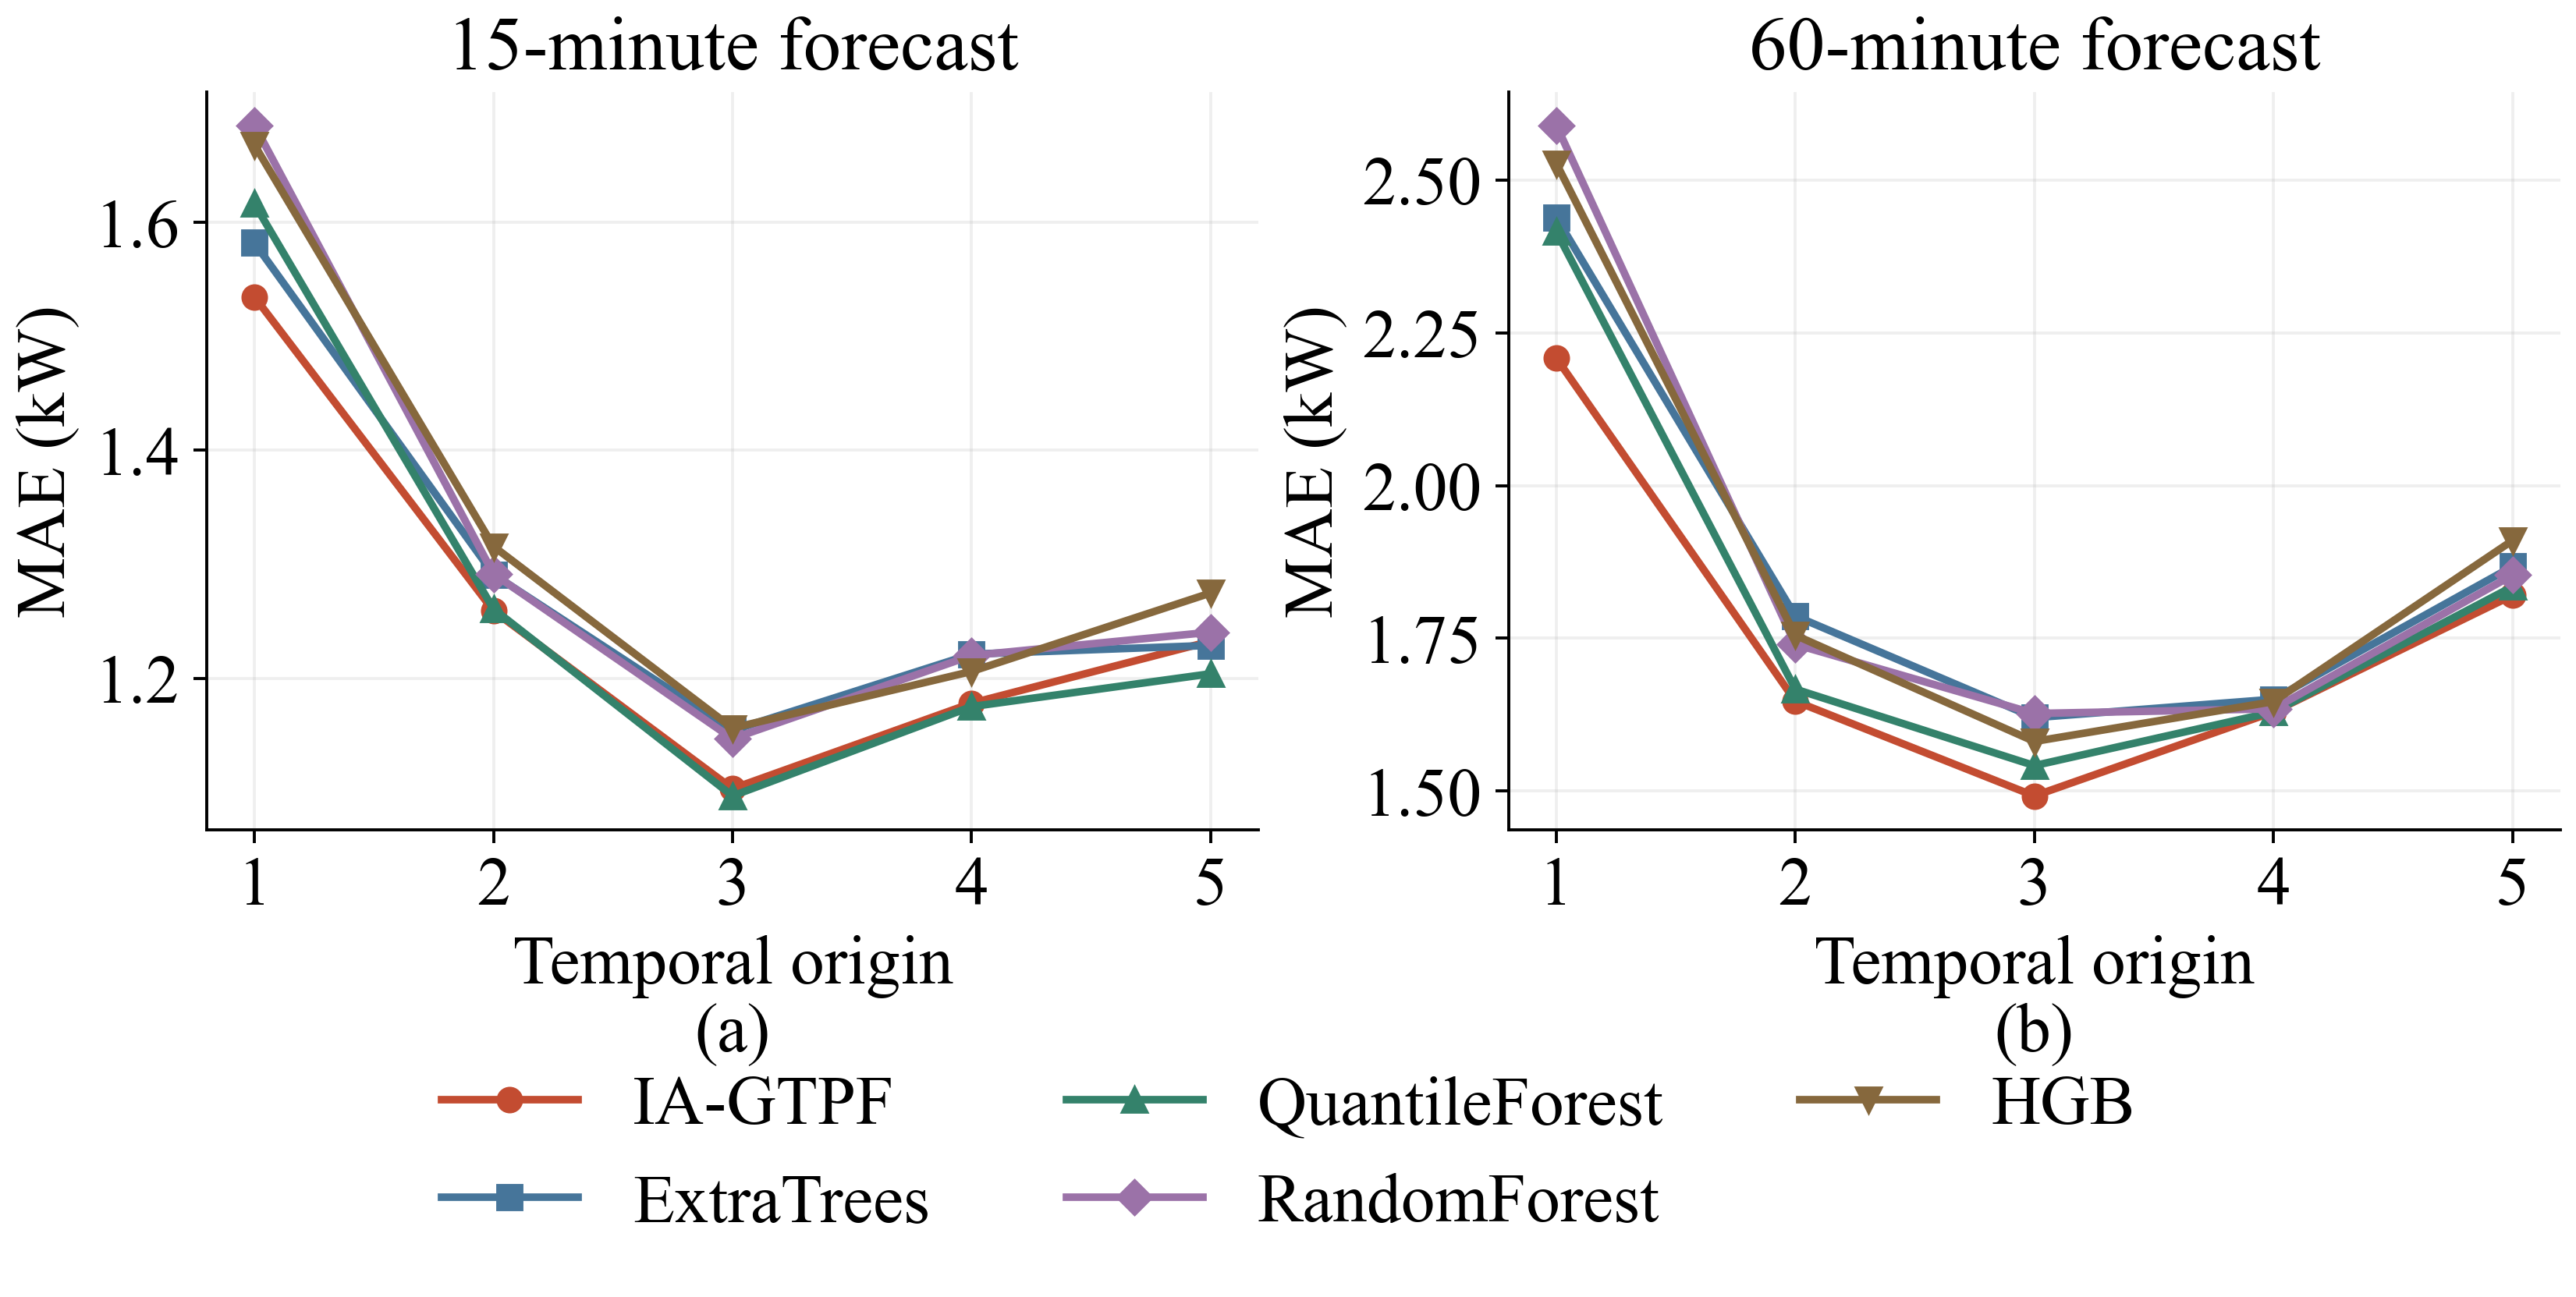

In [21]:
origin_mean=pd.read_csv(VISUAL_DATA/'revision_rolling_origins.csv',index_col=0)
fig,axes=plt.subplots(1,2,figsize=(9.4, 4.8),layout='constrained')
styles={'IA-GTPF':('#c34c31','o'),'ExtraTrees':('#46759a','s'),'QuantileForest':('#34826b','^'),'RandomForest':('#9b72a8','D'),'HGB':('#86683d','v')}
for ax,h in zip(axes,[15,60]):
    for model,(color,marker) in styles.items():
        data=origin_mean.loc[origin_mean.model.eq(model)&origin_mean.horizon_minutes.eq(h)].sort_values('origin')
        ax.plot(data.origin,data.MAE,label=model,color=color,marker=marker,linewidth=2)
    ax.set(xlabel='Temporal origin',ylabel='MAE (kW)',title=f'{h}-minute forecast',xticks=range(1,6));ax.grid(alpha=.2)
outside_legend(fig,axes[0],3)
panel_letters(axes);save_figure(fig,'revision_rolling_origins',origin_mean)


Each point is the seed-averaged result for one chronological origin. Variation across origins shows temporal heterogeneity and prevents interpreting a single holdout as a universal ranking.

## Coverage width

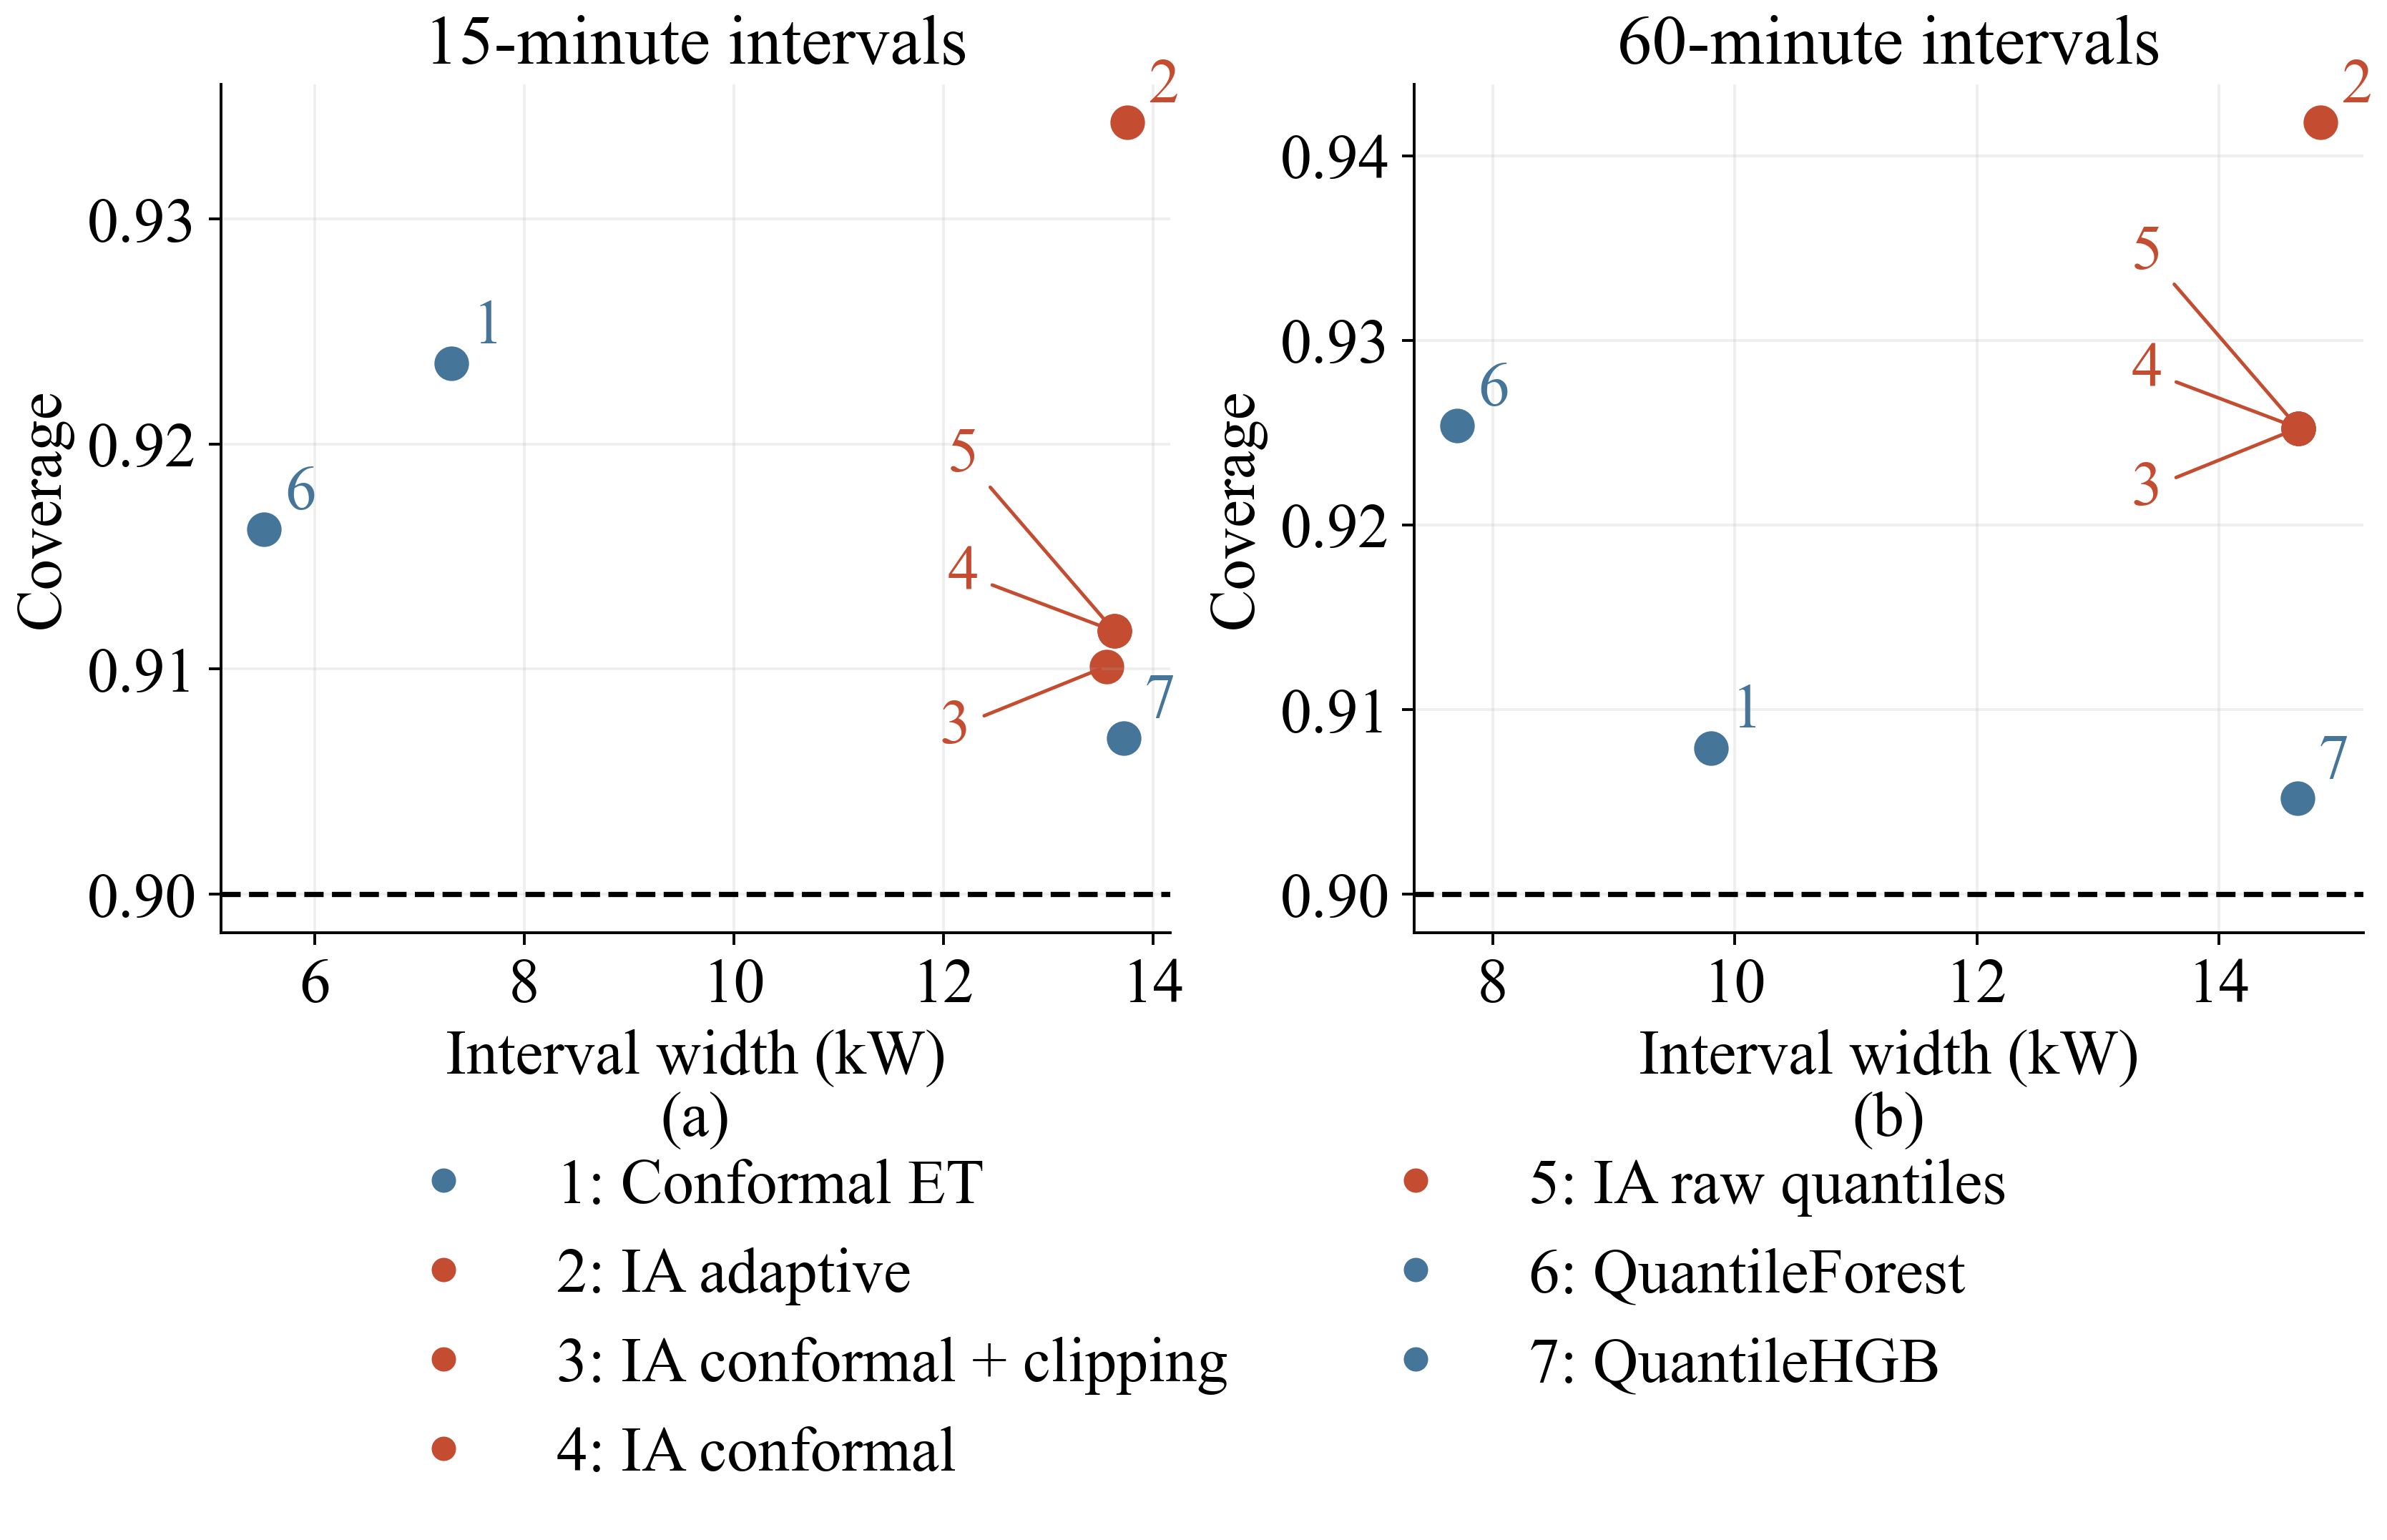

In [22]:
reliability=pd.read_csv(VISUAL_DATA/'revision_coverage_width.csv',index_col=0)
from matplotlib.lines import Line2D
fig,axes=plt.subplots(1,2,figsize=(9.5, 6.2),layout='constrained');legend_labels={}
for ax,h in zip(axes,[15,60]):
    data=reliability.loc[reliability.horizon_minutes.eq(h)].copy()
    for number,row in enumerate(data.itertuples(),1):
        label={'adaptive_conformal_pre_clip':'IA adaptive','dedicated_conformal_post_clip':'IA conformal + clipping','dedicated_conformal_pre_clip':'IA conformal','raw_quantiles_pre_clip':'IA raw quantiles'}.get(row.method,row.model).replace('Conformalized ExtraTrees','Conformal ET')
        if number in legend_labels:assert legend_labels[number]==label
        legend_labels[number]=label
        color='#c34c31' if row.model=='IA-GTPF' else '#46759a'
        ax.scatter(row.width,row.coverage,s=80,color=color)
        offset={3:(-48,-22),4:(-48,12),5:(-48,46)}.get(number,(6,6))
        ax.annotate(str(number),(row.width,row.coverage),xytext=offset,textcoords='offset points',fontsize=18,
                    color=color,arrowprops={'arrowstyle':'-','color':color,'lw':1} if number in [3,4,5] else None)
    ax.axhline(.9,color='black',linestyle='--',label='Nominal 90%');ax.set(xlabel='Interval width (kW)',ylabel='Coverage',title=f'{h}-minute intervals');ax.grid(alpha=.2)
handles=[Line2D([],[],linestyle='',marker='o',color='#c34c31' if label.startswith('IA ') else '#46759a',label=f'{number}: {label}') for number,label in legend_labels.items()]
fig.legend(handles=handles,loc='outside lower center',ncol=2,fontsize=18,frameon=False)

panel_letters(axes);save_figure(fig,'revision_coverage_width',reliability)


The dashed line marks nominal 90% coverage. Width and distance from nominal coverage must be considered jointly; maximum coverage alone does not identify the best interval method.

## Paired improvement and block-length sensitivity

Source: already computed paired tests and bootstrap intervals; no bootstrap rerun.

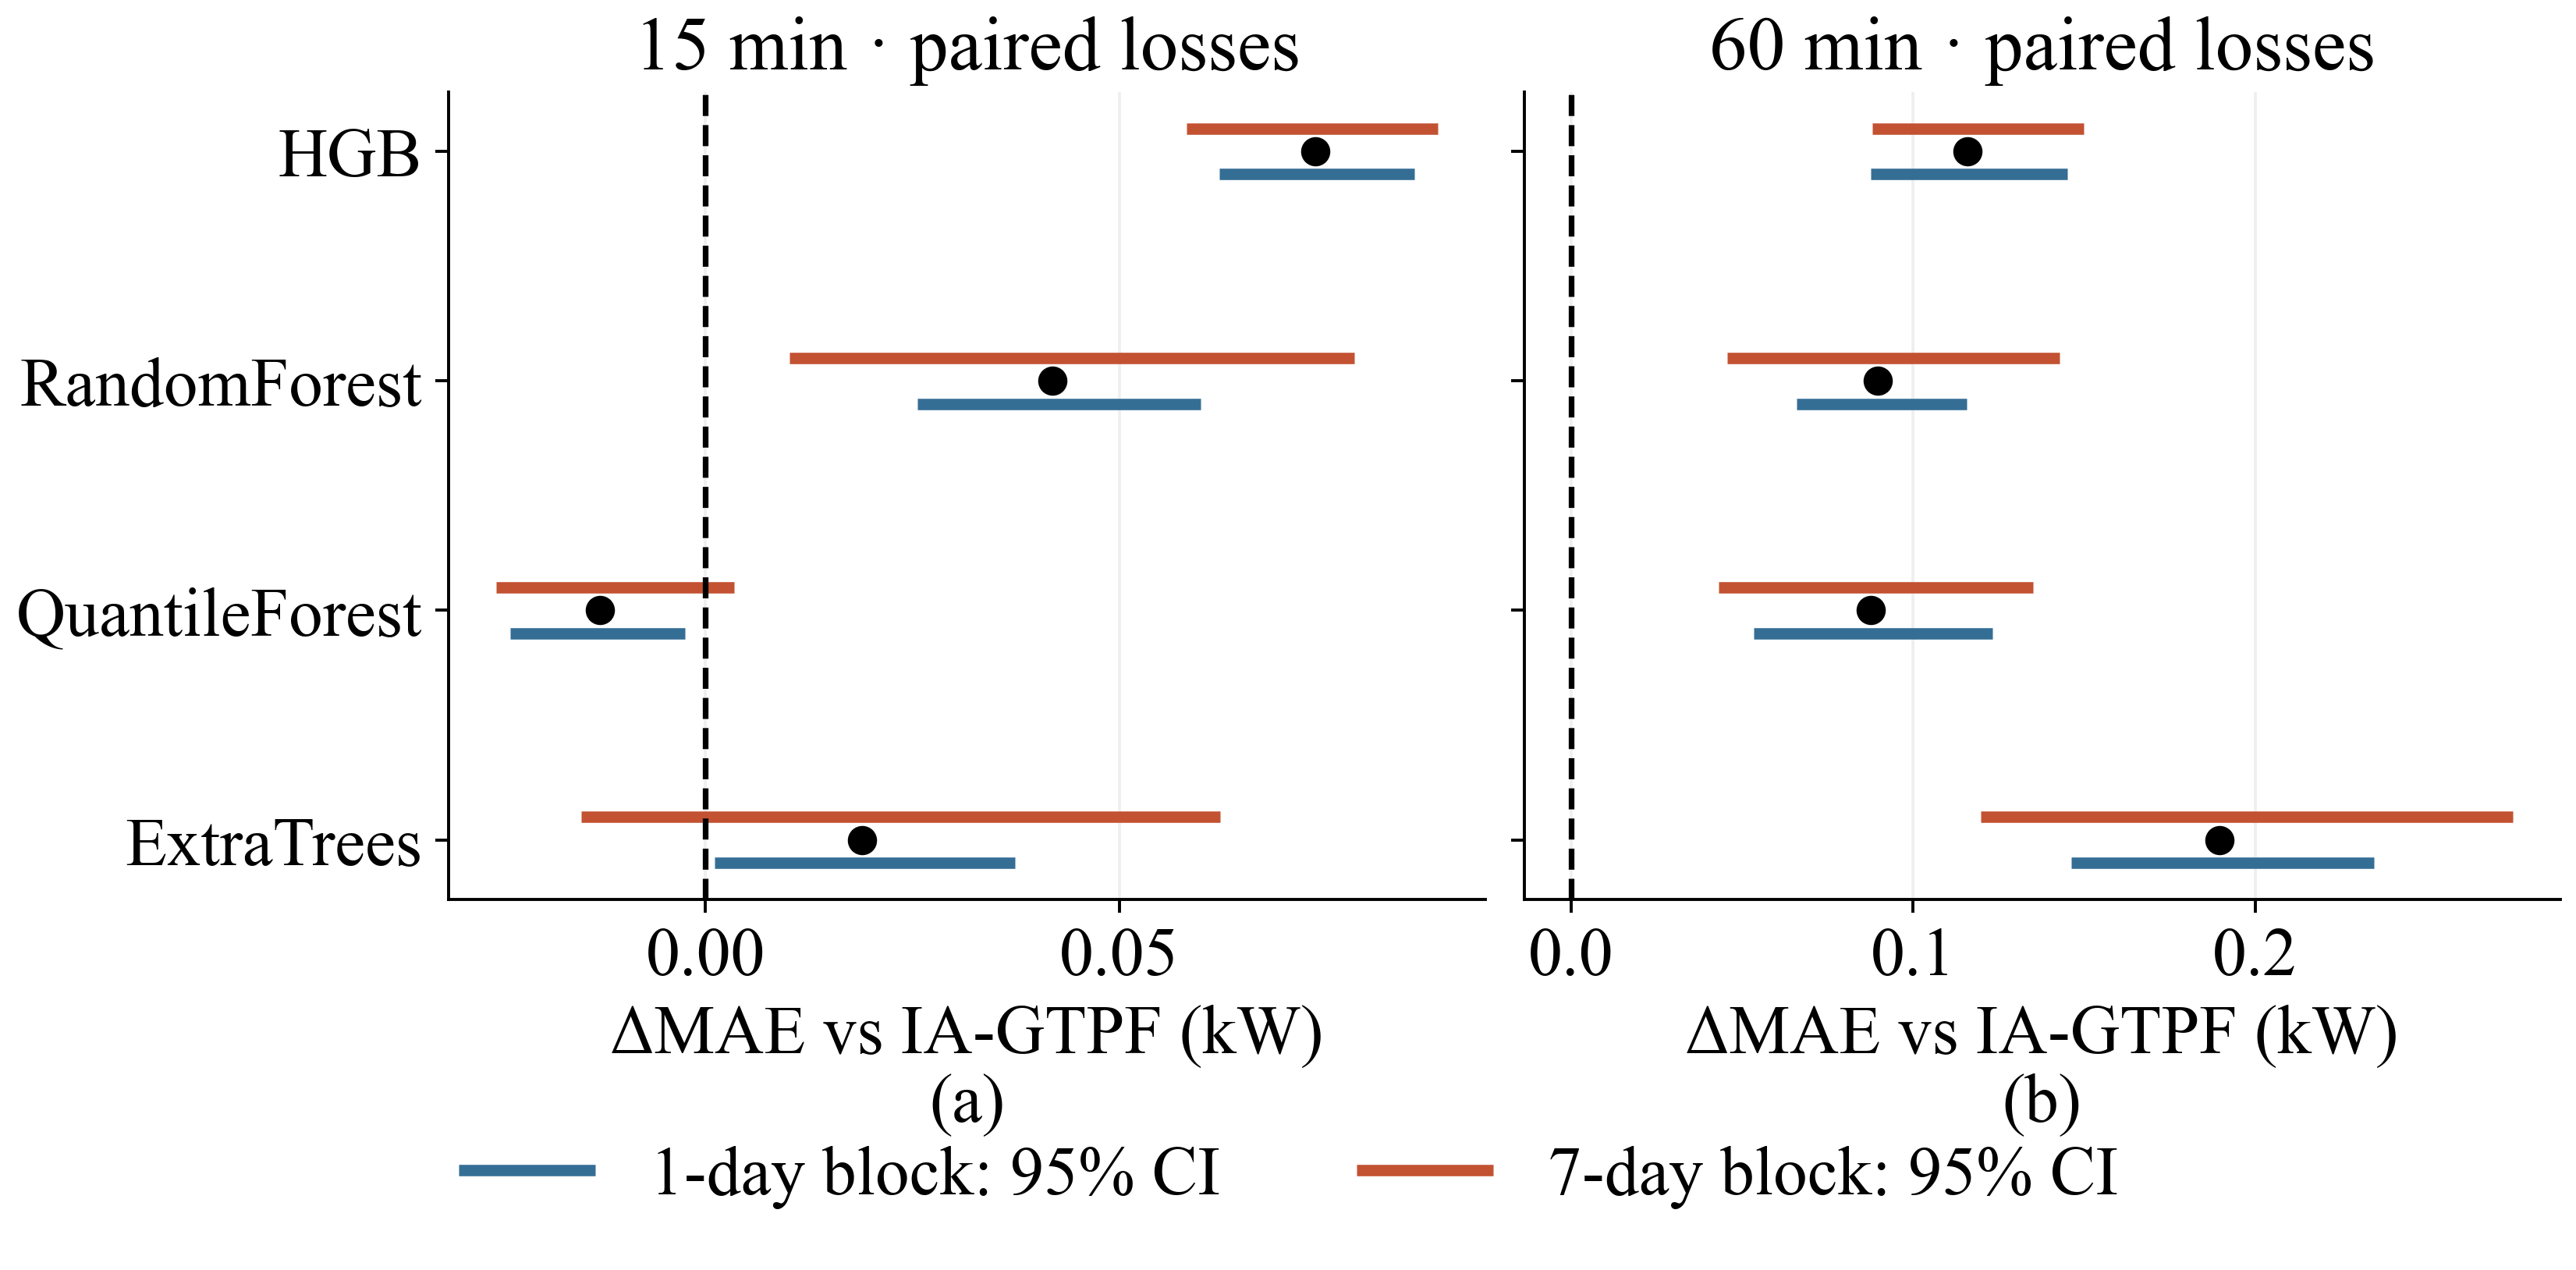

In [23]:
d=pd.read_csv(TABLE_DIR/'paired_statistical_summary.csv').query('experiment=="main"');fig,axes=plt.subplots(1,2,figsize=(9.4, 4.7),layout='constrained',sharey=True)
for ax,h in zip(axes,[15,60]):
    z=d.loc[d.horizon_minutes.eq(h)];y=np.arange(len(z))
    ax.hlines(y-.1,z.CI_95_low,z.CI_95_high,color=C['blue'],lw=3,label='1-day block: 95% CI');ax.hlines(y+.1,z.CI_7day_low,z.CI_7day_high,color=C['orange'],lw=3,label='7-day block: 95% CI');ax.scatter(z.mean_delta_MAE,y,color='black',s=45,zorder=3)
    ax.axvline(0,color='black',ls='--');ax.set(yticks=y,yticklabels=z.comparator,xlabel='ΔMAE vs IA-GTPF (kW)',title=f'{h} min · paired losses');ax.grid(axis='x',alpha=.2)
outside_legend(fig,axes[0],2);panel_letters(axes);save_figure(fig,'revision_paired_improvement_uncertainty',d)


Positive differences favor IA-GTPF. The 15-minute ExtraTrees comparison is not robust to seven-day blocks; the QuantileForest comparison also prevents a uniform-superiority claim. Multiplicity-adjusted p-values remain in the statistical tables.

## Chronological example with calibrated 90% intervals

Source: frozen calibrated forecasts, measured test targets only; x-axis uses target time t+h.

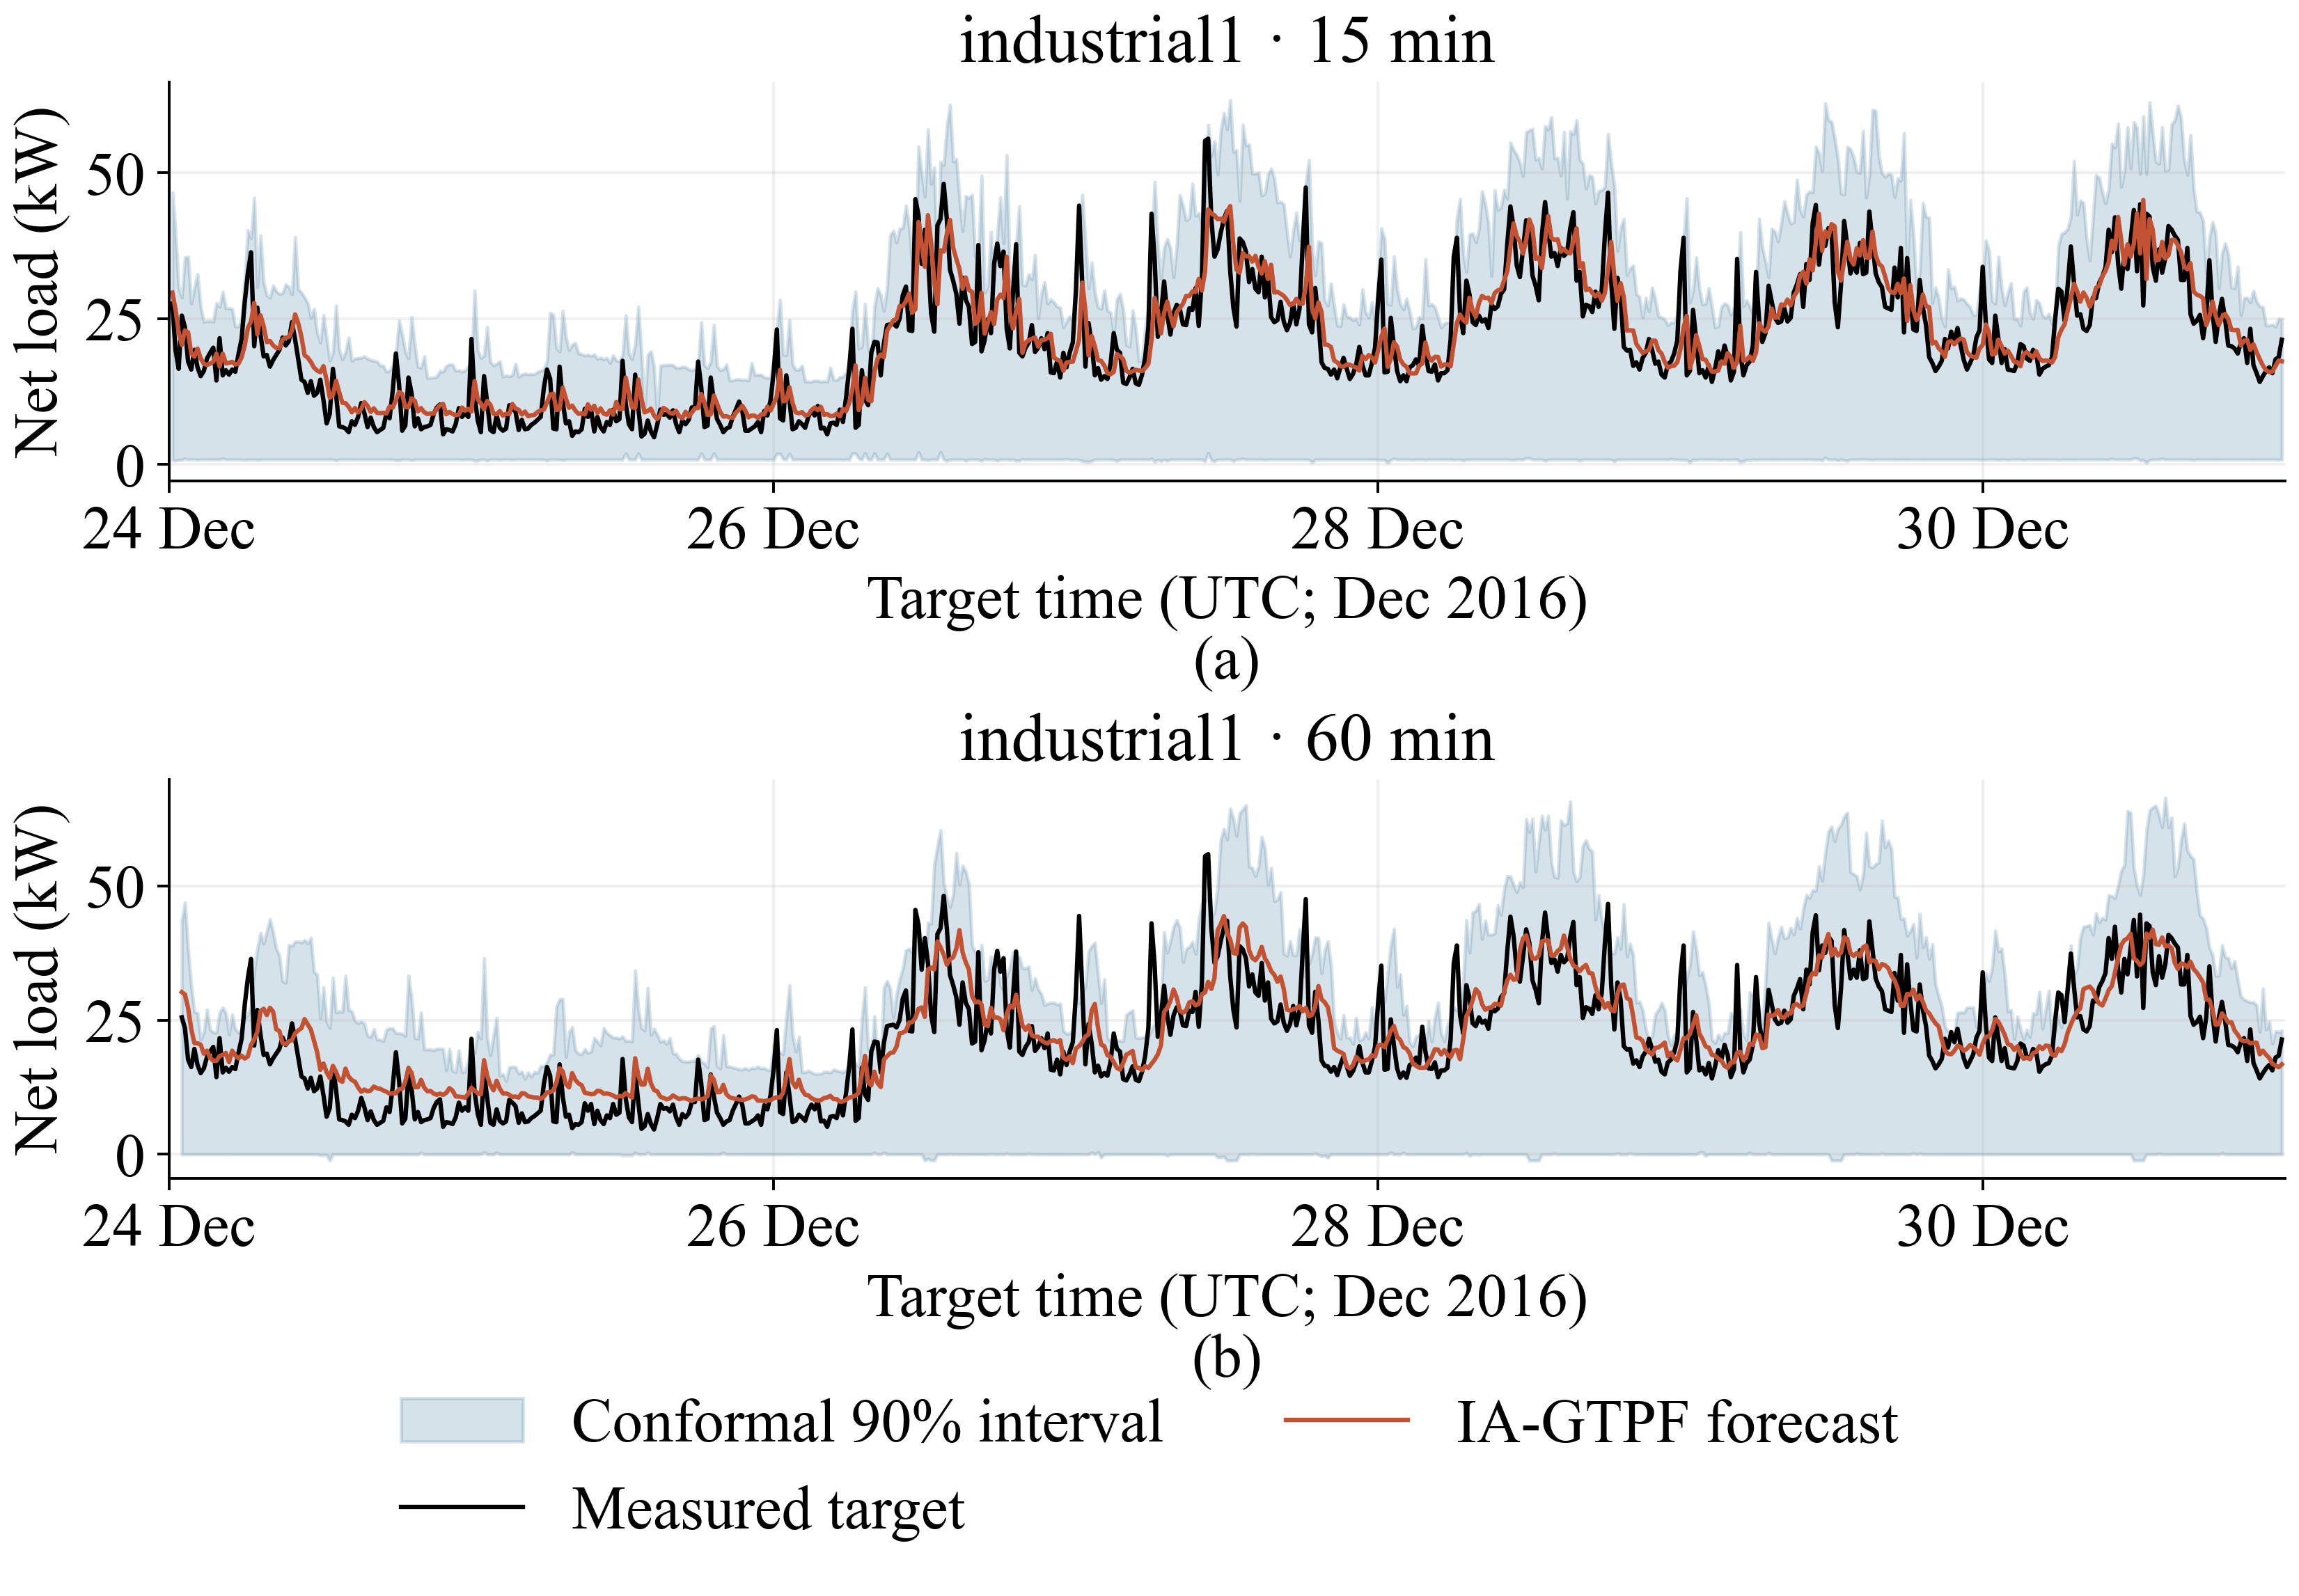

In [29]:
saved_example=pd.read_csv(VISUAL_DATA/'revision_forecast_intervals_example.csv',index_col=0)
fig,axes=plt.subplots(2,1,figsize=(9.4, 6.6),layout='constrained');rows=[]
for ax,h in zip(axes,[1,4]):
    d=saved_example.loc[saved_example.horizon_minutes.eq(15*h)].copy();d=d.loc[d.site.eq('industrial1')].copy();d['target_timestamp']=pd.to_datetime(d.target_timestamp,utc=True)
    start=d.target_timestamp.min().floor('D');d=d.loc[d.target_timestamp.lt(start+pd.Timedelta(days=7))].sort_values('target_timestamp');rows.append(d)
    ax.fill_between(d.target_timestamp,d.lower,d.upper,color=C['blue'],alpha=.2,label='Conformal 90% interval');ax.plot(d.target_timestamp,d.actual,color='black',lw=1.3,label='Measured target');ax.plot(d.target_timestamp,d.pred,color=C['orange'],lw=1.3,label='IA-GTPF forecast')
    ax.set(ylabel='Net load (kW)',title=f'industrial1 · {15*h} min');ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'));ax.xaxis.set_major_locator(mdates.DayLocator(interval=2));ax.set_xlim(start,start+pd.Timedelta(days=7));ax.set_xticks(pd.date_range(start,periods=4,freq='2D'));ax.set_xlabel('Target time (UTC; Dec 2016)');ax.grid(alpha=.2)
outside_legend(fig,axes[0],2)
panel_letters(axes);save_figure(fig,'revision_forecast_intervals_example',pd.concat(rows,ignore_index=True))


The site, seed and first seven test days were selected by a fixed ordering rather than forecast quality. This illustrative interval is not evidence of conditional coverage; the full-test diagnostics below provide that assessment.

## Quantile-specific pinball loss

Source: frozen quantile losses; comparable full-test measured targets.

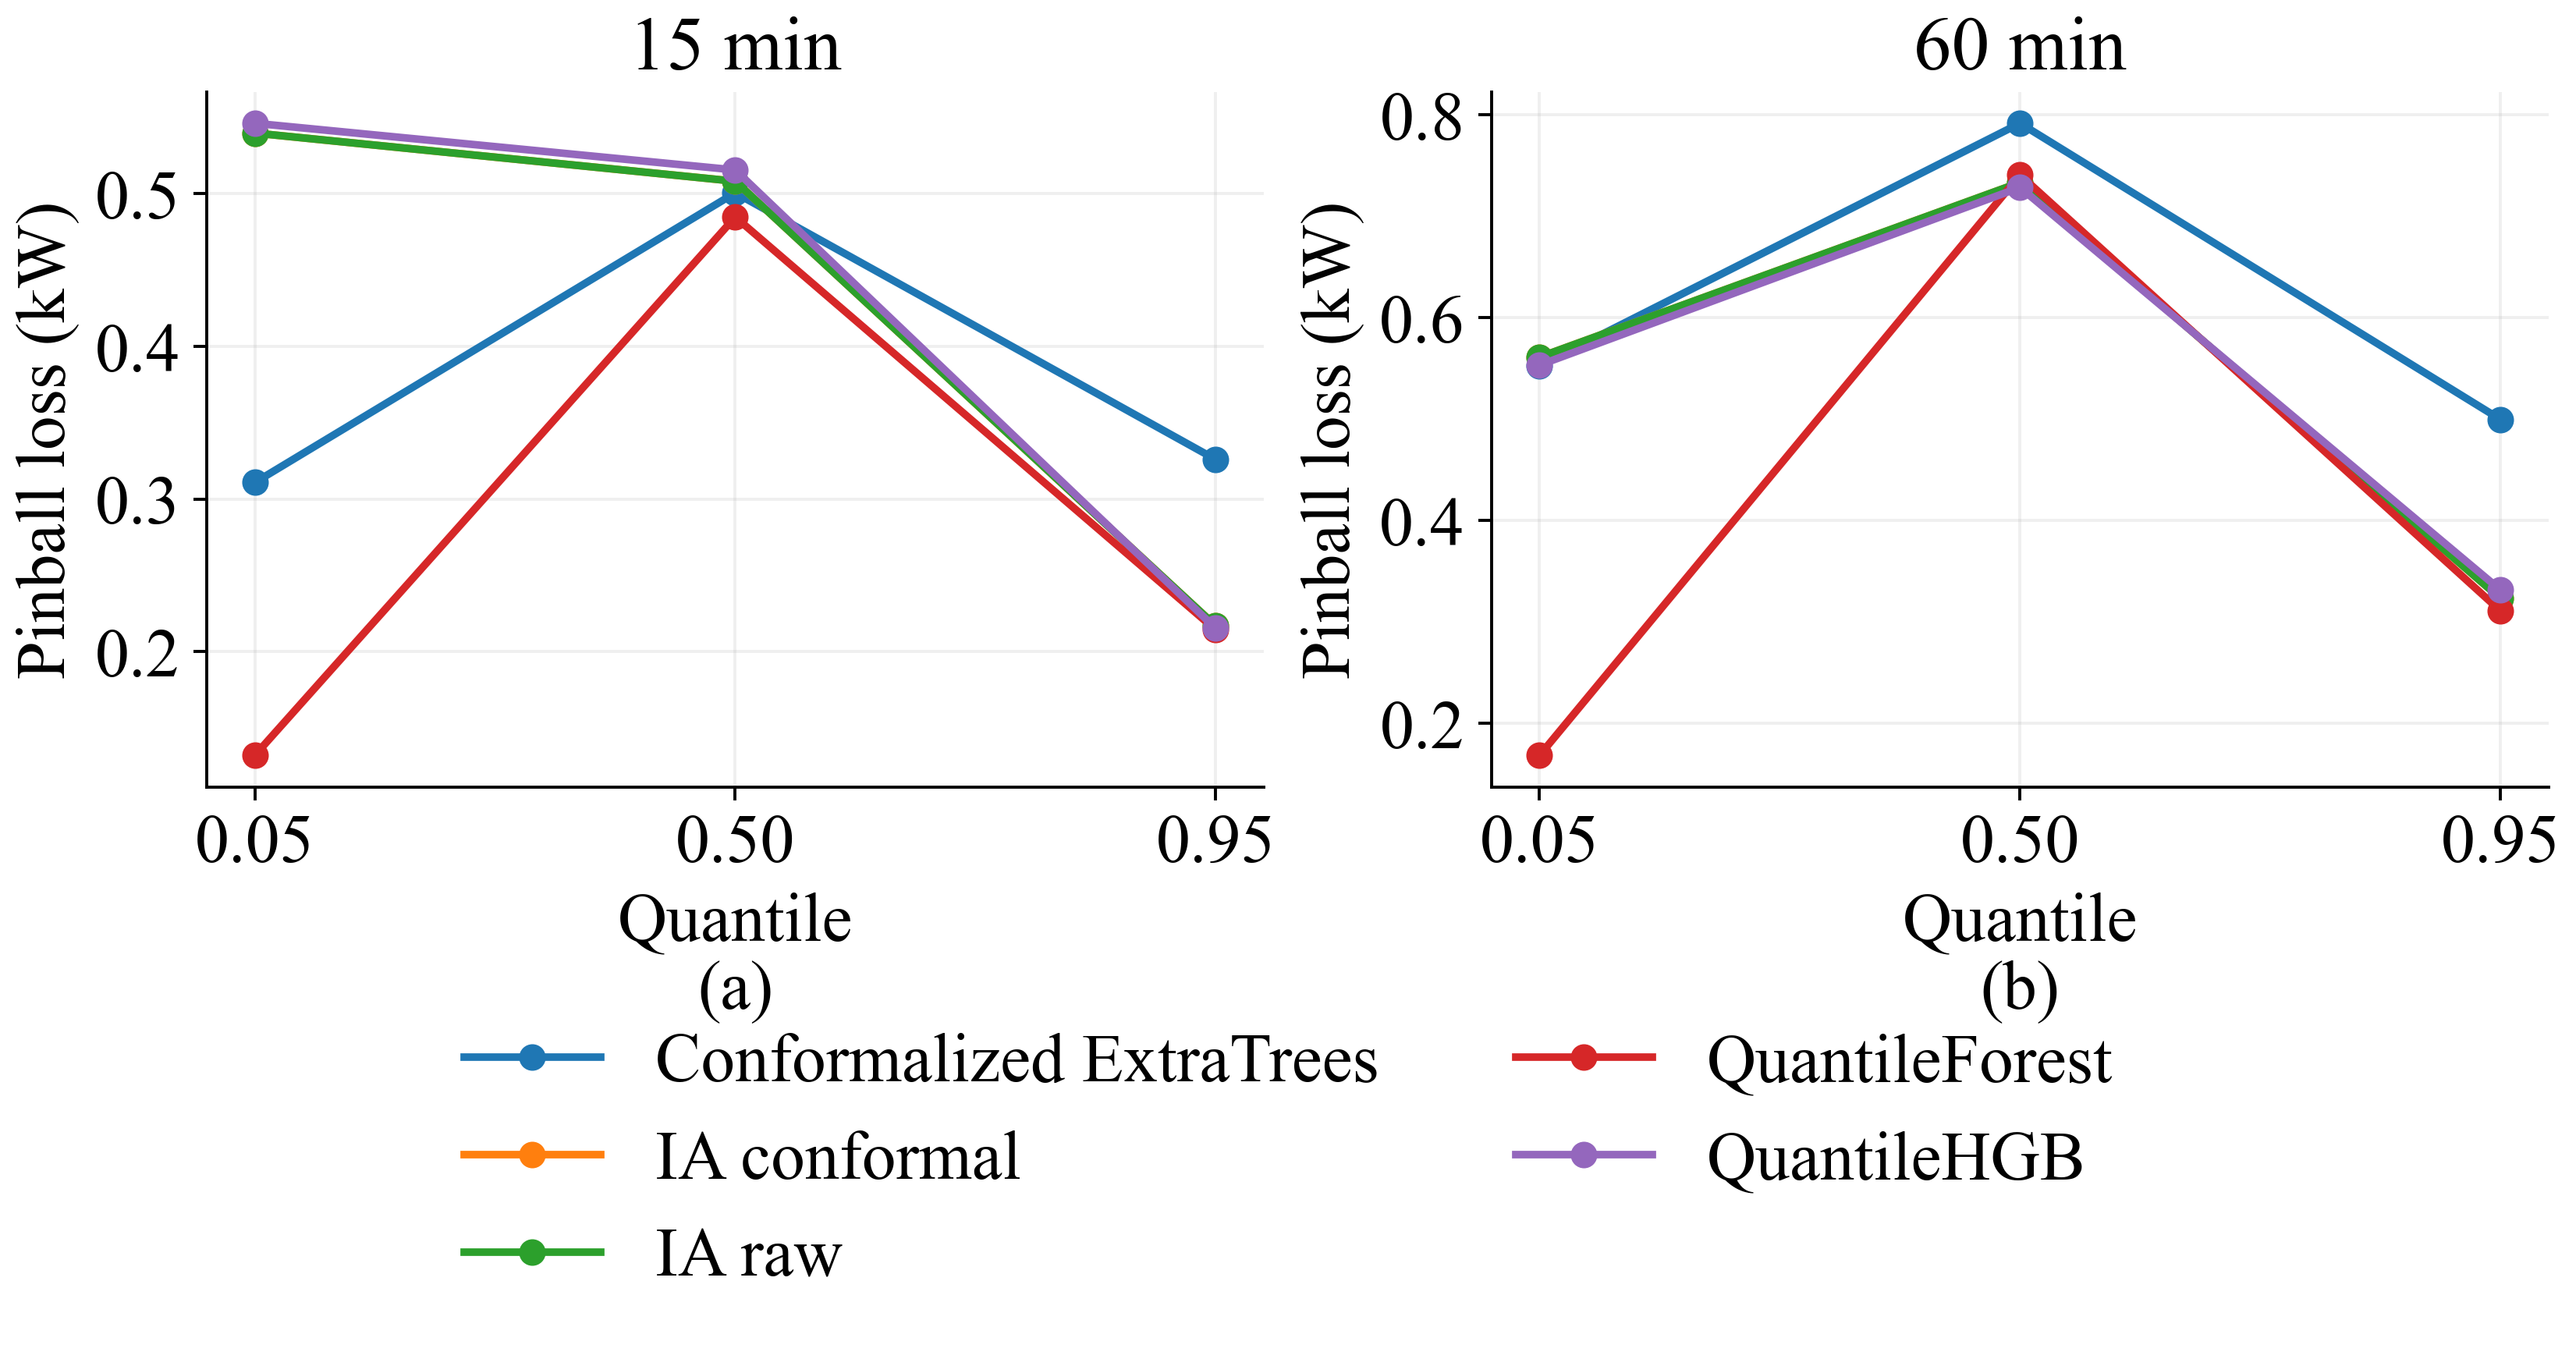

In [25]:
g=pd.read_csv(VISUAL_DATA/'revision_pinball_loss_by_quantile.csv',index_col=[0,1])
fig,axes=plt.subplots(1,2,figsize=(9.4, 5.0),layout='constrained')
for ax,h in zip(axes,[15,60]):
    for label,row in g.xs(h).iterrows():ax.plot([.05,.5,.95],row.values,marker='o',lw=2,label=label)
    ax.set(xticks=[.05,.5,.95],xlabel='Quantile',ylabel='Pinball loss (kW)',title=f'{h} min');ax.grid(alpha=.2)
outside_legend(fig,axes[0],2);panel_letters(axes);save_figure(fig,'revision_pinball_loss_by_quantile',g)


Pinball loss is evaluated at the fitted quantiles 0.05, 0.50 and 0.95. Overlapping curves indicate similar quantile errors.

## Conditional interval coverage and width

Source: saved conditional interval metrics; mean over five seeds.

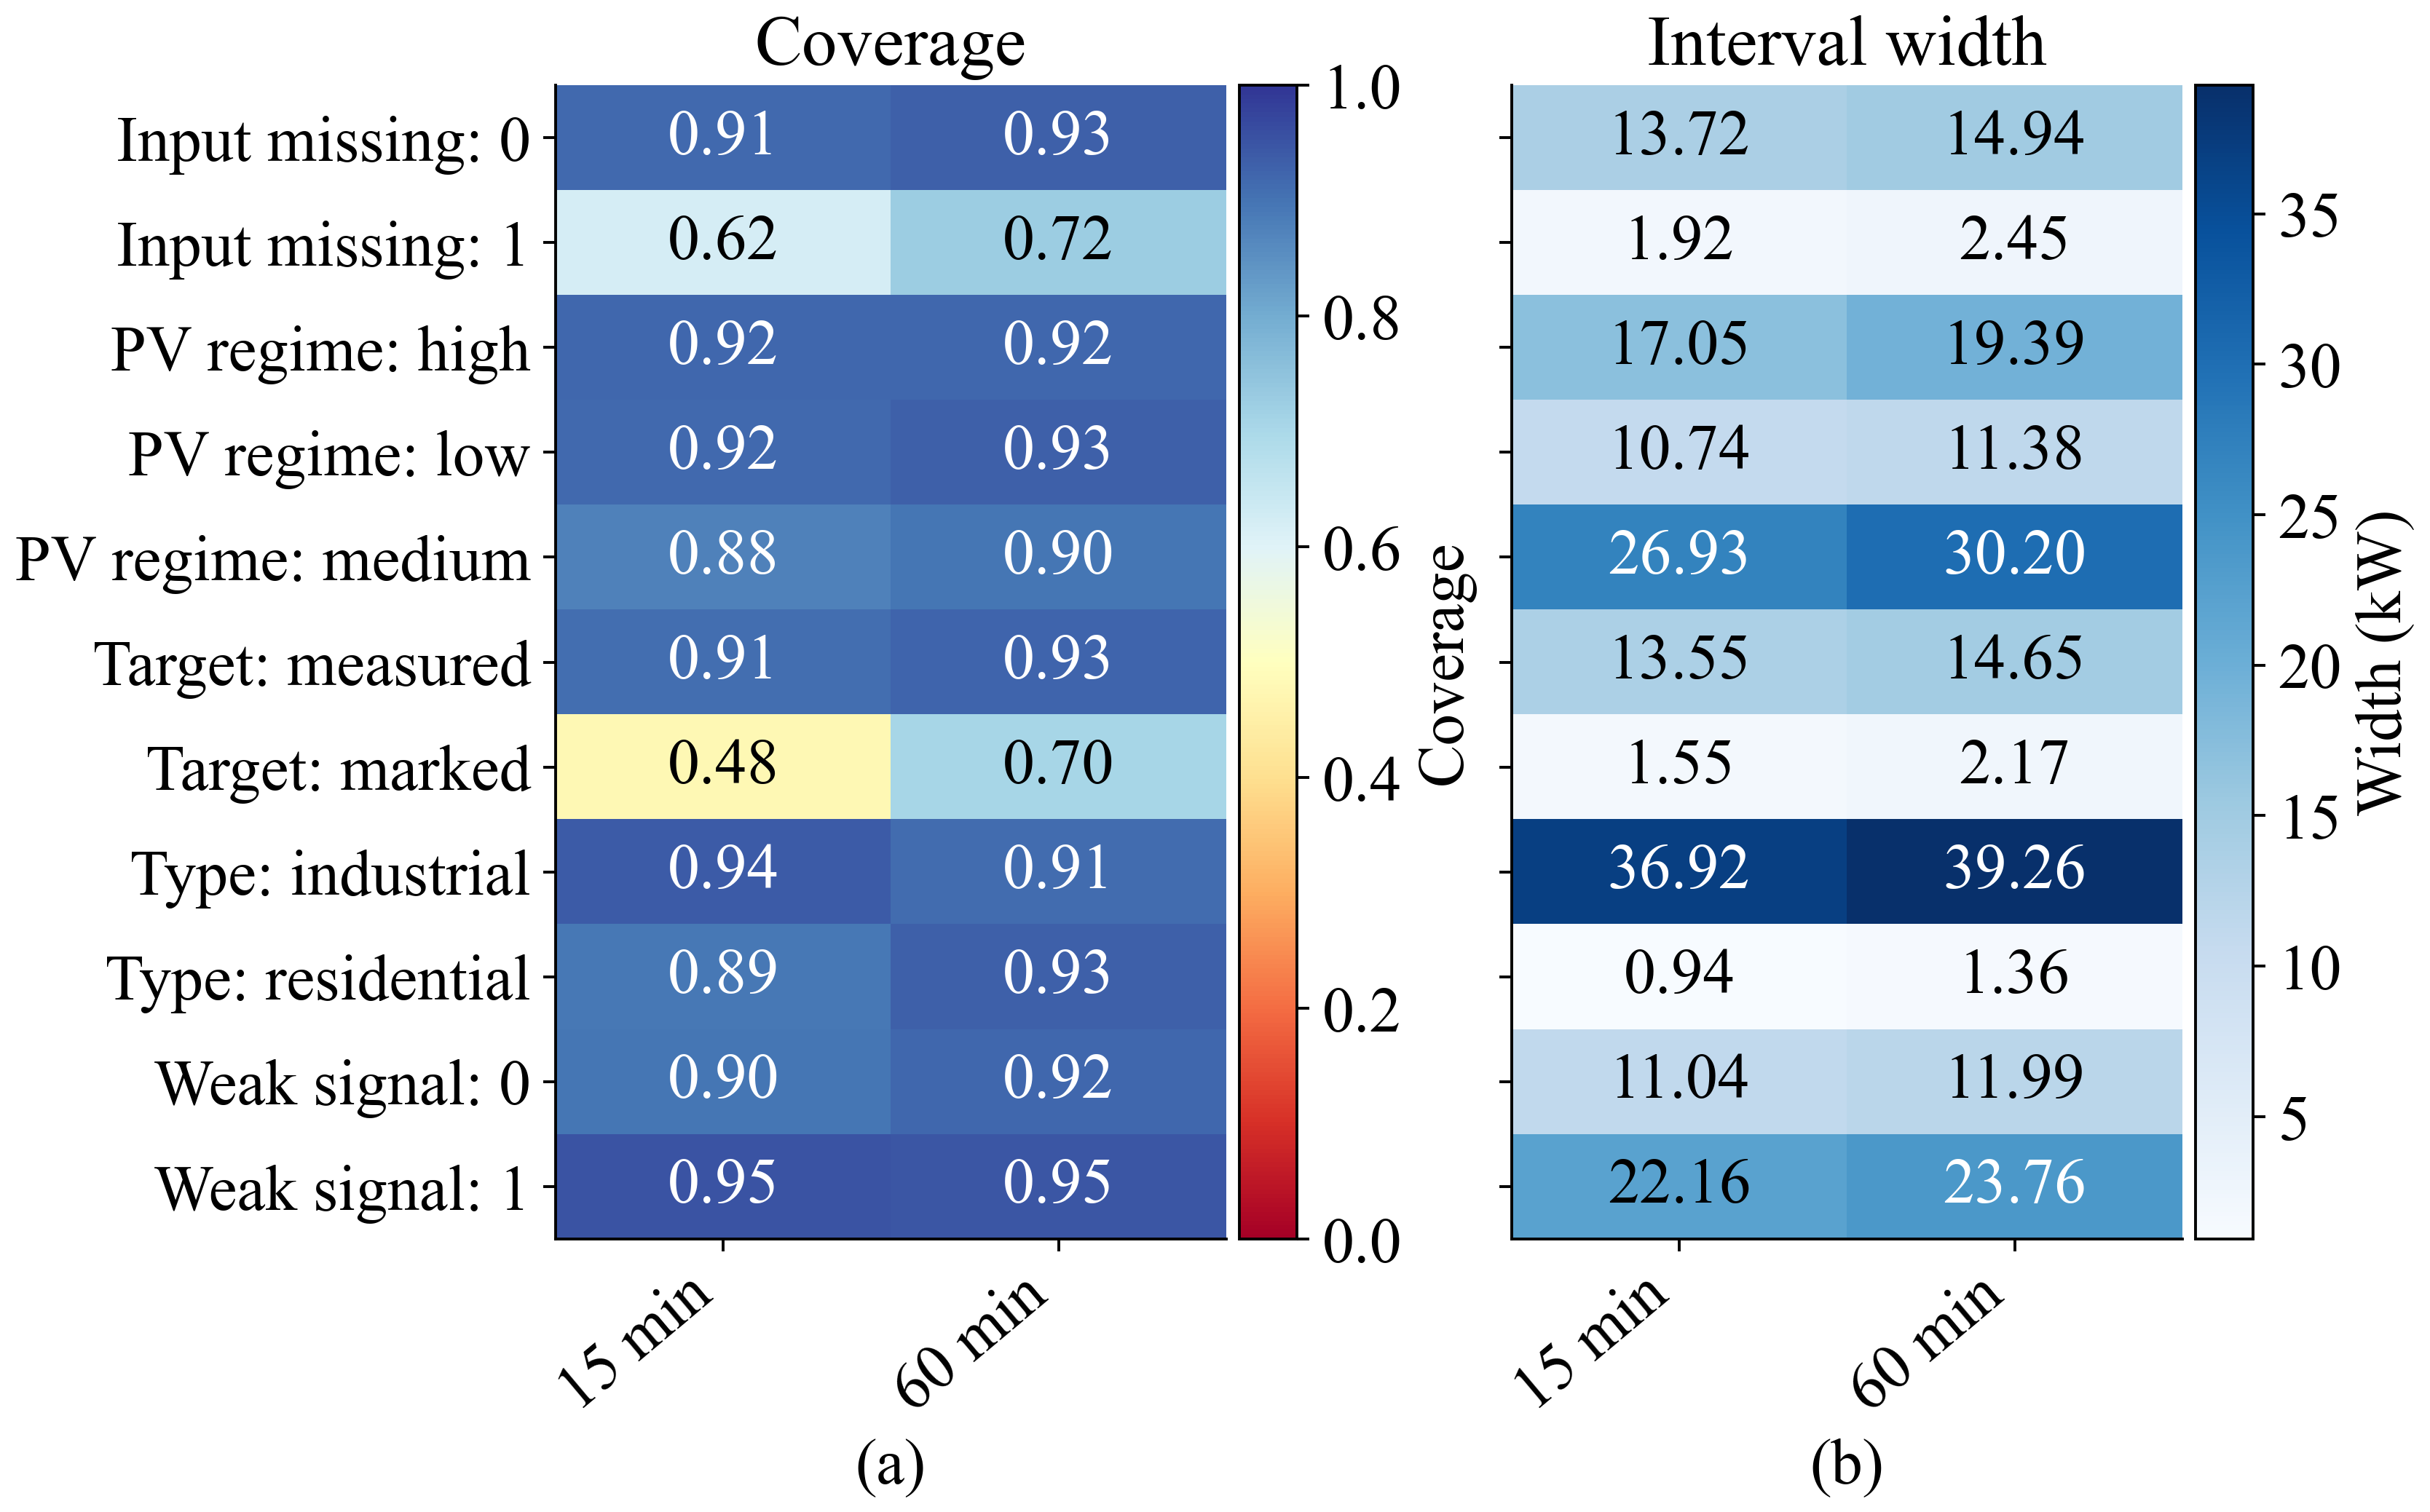

In [30]:
g=pd.read_csv(VISUAL_DATA/'revision_conditional_interval_matrices.csv',index_col=[0,1])
cover=g.coverage.unstack();width=g.width.unstack();cover.columns=width.columns=['15 min','60 min']
cover.index=width.index=[str(v).replace('Input unavailable','Input missing').replace('supplier marked','marked') for v in cover.index]
fig,axes=plt.subplots(1,2,figsize=(9.5, 5.9),layout='constrained',sharey=True);labelled_matrix(axes[0],cover,'Coverage',cmap='RdYlBu',vmin=0,vmax=1,cbar_label='Coverage');labelled_matrix(axes[1],width,'Interval width',cmap='Blues',cbar_label='Width (kW)')
panel_letters(axes);save_figure(fig,'revision_conditional_interval_matrices',g)


The target-provenance rows distinguish primary measured targets from supplier-marked secondary references. Causal input missingness is the revised meaning of high_interpolation_regime; weak-signal thresholds are train-fitted. Counts are included in the numeric companion.

“Target: marked” denotes supplier-marked interpolated targets.

## Building-level error matrices

How does forecast error vary across the nine sites? The matrices use the frozen conditional point metrics and five-seed means.

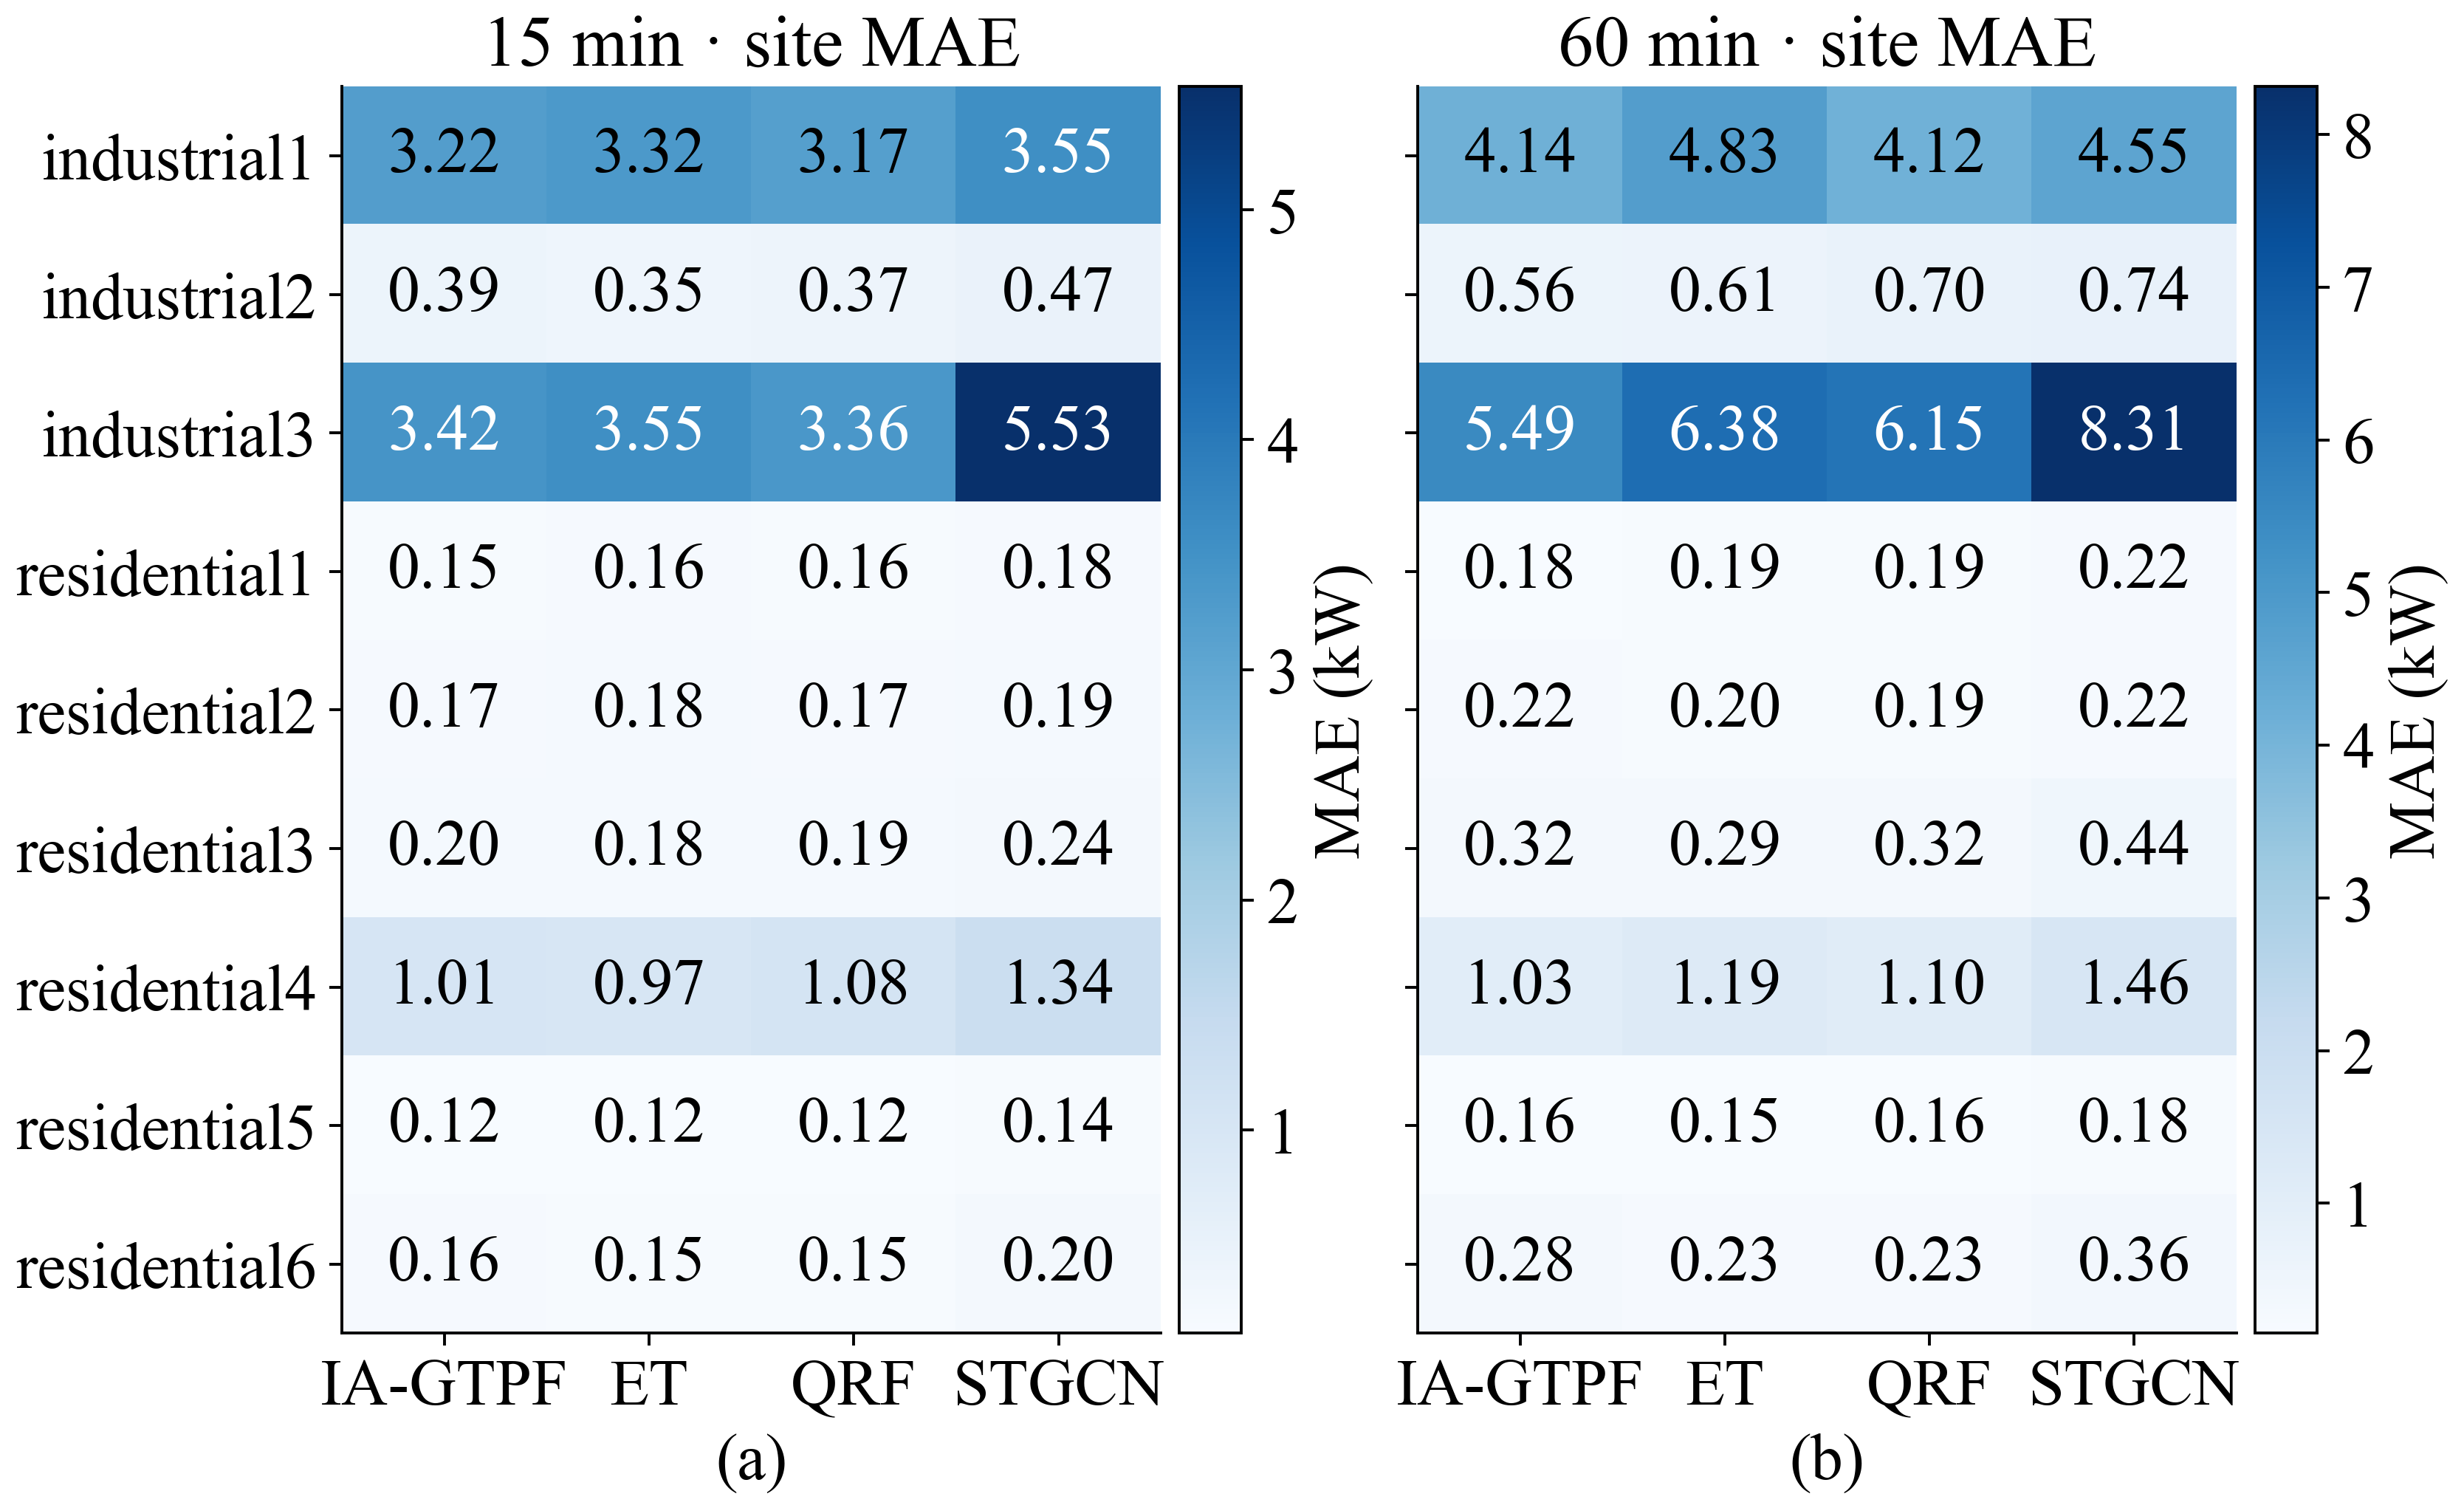

In [31]:
g=pd.read_csv(VISUAL_DATA/'revision_building_error_heatmaps.csv',index_col=[0,1,2]).MAE
fig,axes=plt.subplots(1,2,figsize=(9.5, 5.8),layout='constrained',sharey=True)
for ax,h in zip(axes,[15,60]):
    mat=g.xs(h,level='horizon_minutes').unstack('model').reindex(columns=['IA-GTPF','ExtraTrees','QuantileForest','STGCN']);mat.columns=['IA-GTPF','ET','QRF','STGCN'];labelled_matrix(ax,mat,f'{h} min · site MAE',cmap='Blues',cbar_label='MAE (kW)');ax.tick_params(axis='x',rotation=0)
    for label in ax.get_xticklabels():label.set_ha('center')
panel_letters(axes);save_figure(fig,'revision_building_error_heatmaps',g.to_frame('MAE'))


Site-level absolute errors reflect different load scales. The matrices show heterogeneity rather than a common error level across industrial and residential buildings.

ET denotes ExtraTrees; QRF denotes QuantileForest. Panel (a): 15 minutes; panel (b): 60 minutes.

## Weak-signal and missing-input forecasting regimes

Source: saved conditional point metrics; identical definitions across models.

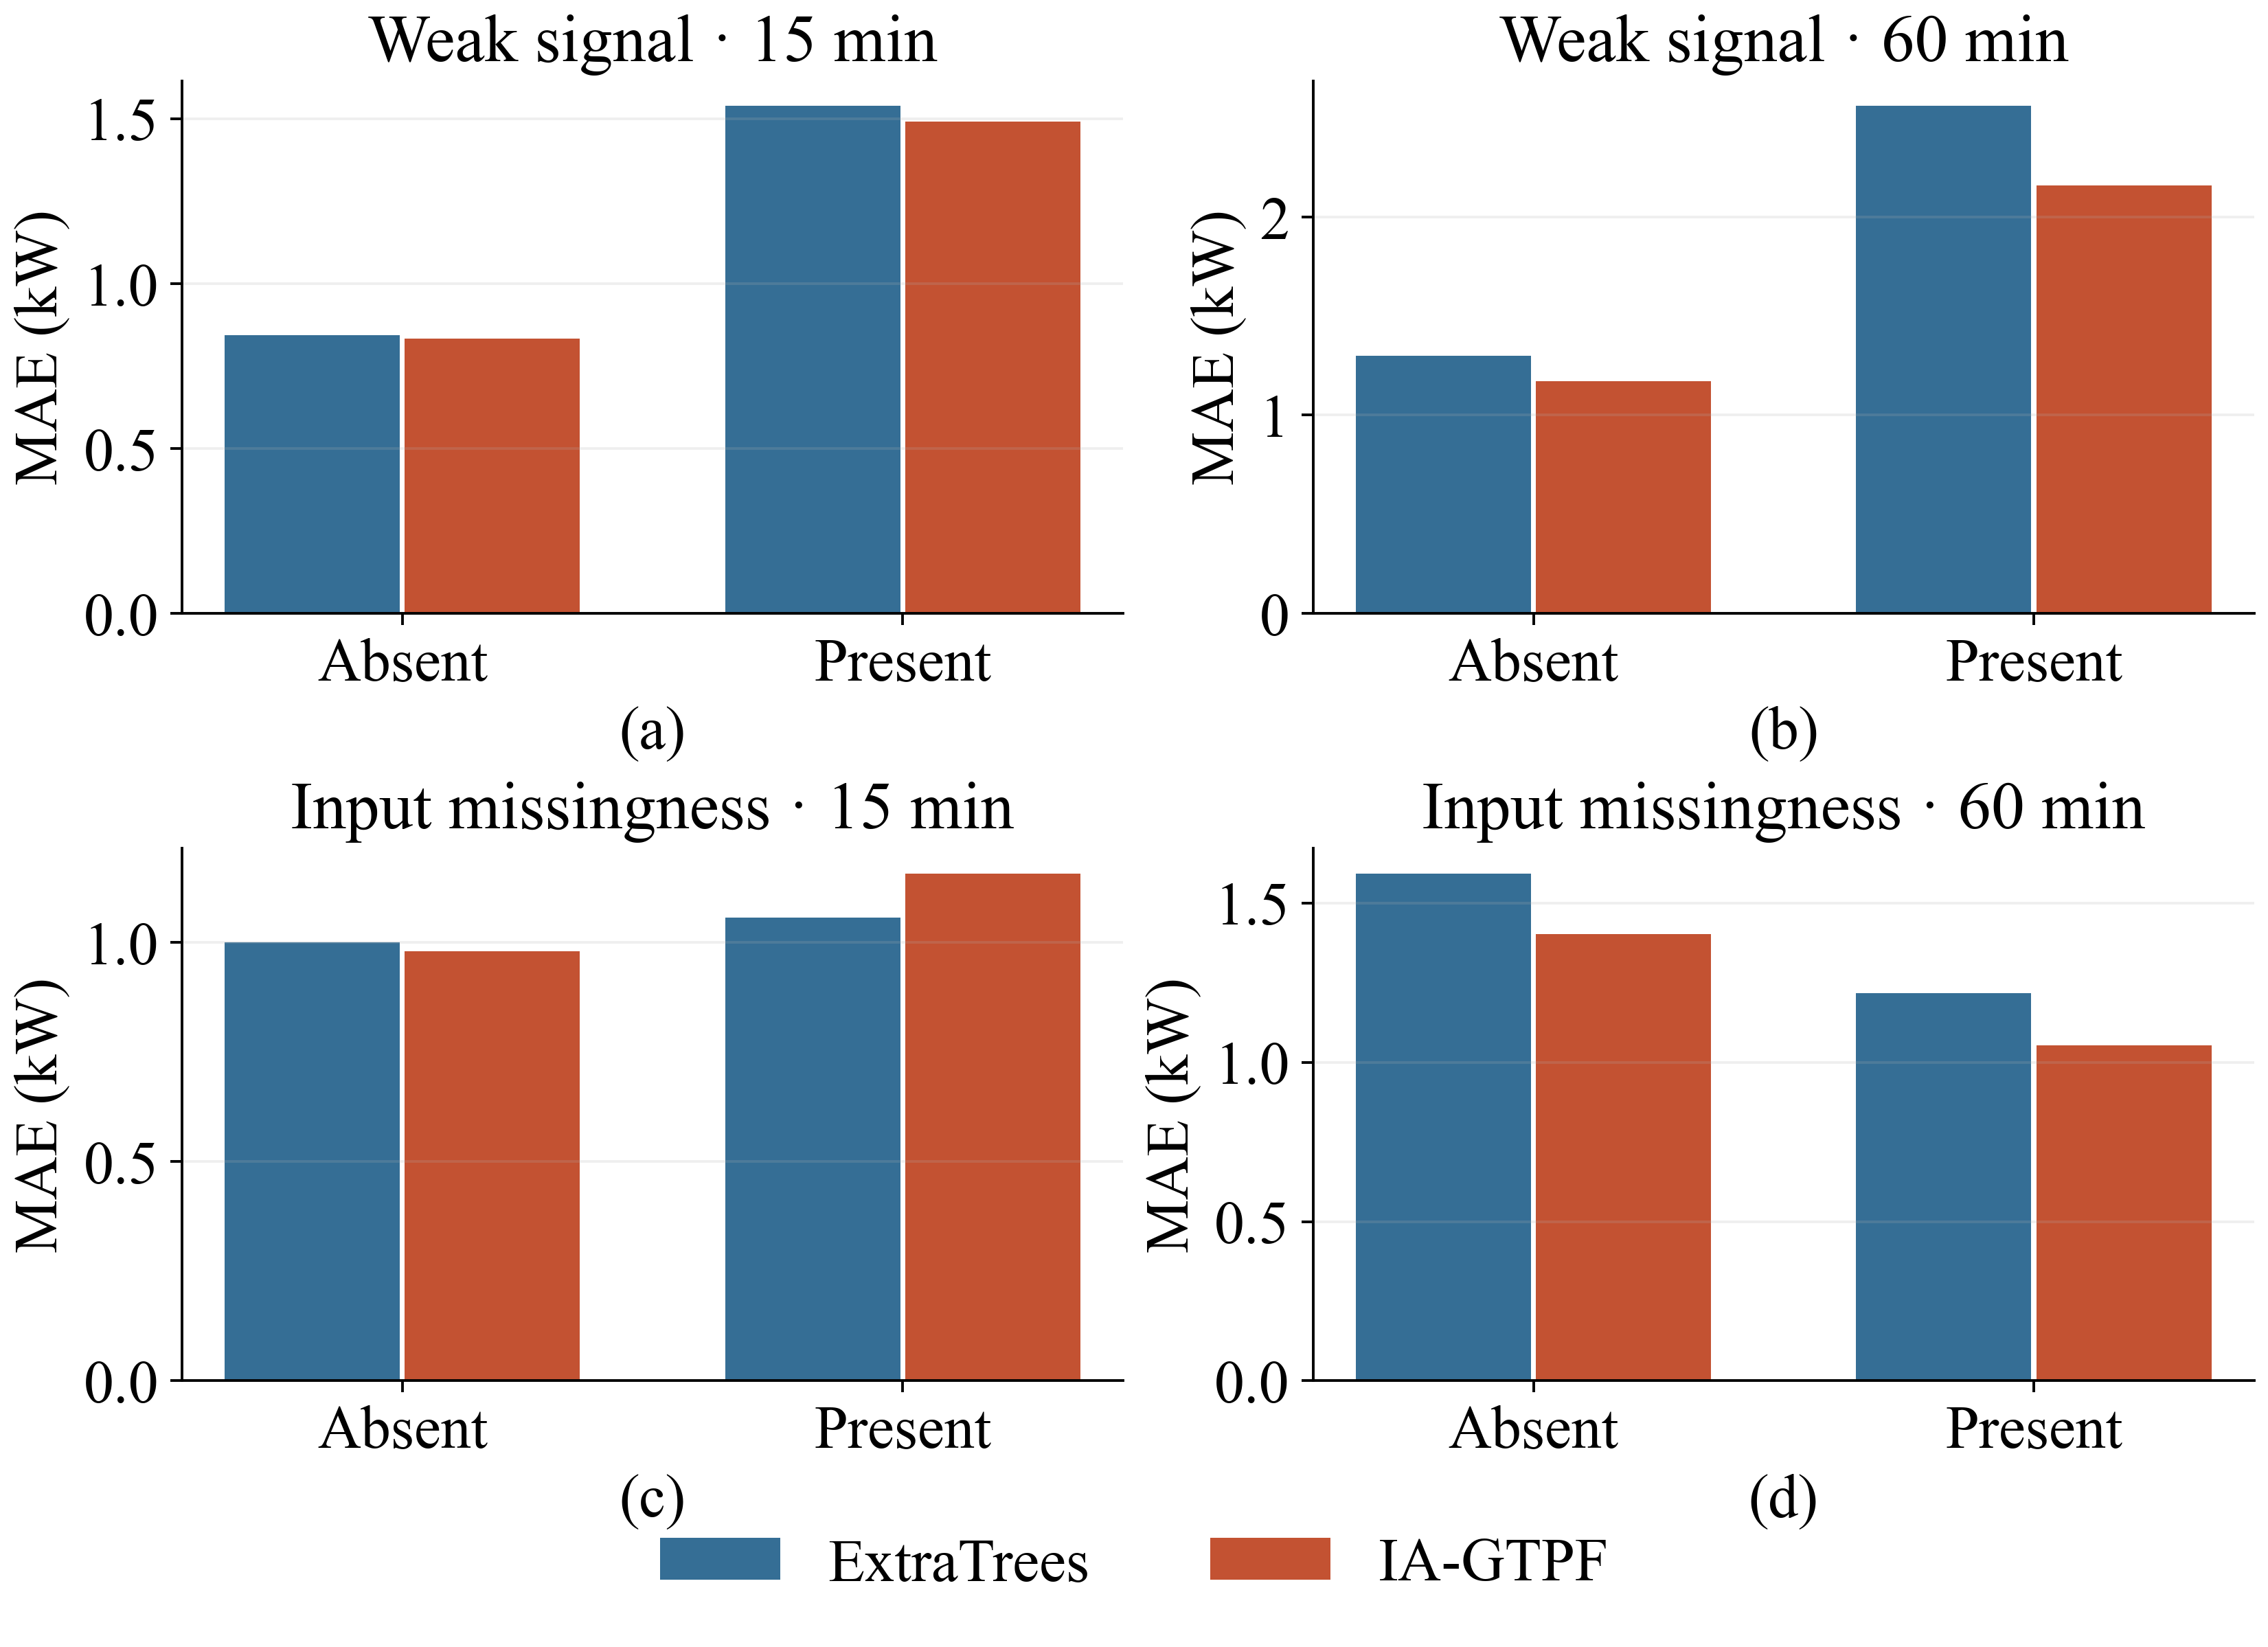

In [28]:
g=pd.read_csv(VISUAL_DATA/'revision_weak_signal_missing_input_performance.csv',index_col=0,dtype={'value':str})
fig,axes=plt.subplots(2,2,figsize=(9.4, 6.9),layout='constrained')
for i,(cond,title) in enumerate([('weak_signal_regime','Weak signal'),('high_interpolation_regime','Input missingness')]):
    for j,h in enumerate([15,60]):
        ax=axes[i,j]
        for offset,(model,color) in zip([-.18,.18],[('ExtraTrees',C['blue']),('IA-GTPF',C['orange'])]):
            z=g.loc[g.condition.eq(cond)&g.model.eq(model)&g.horizon_minutes.eq(h)].set_index('value').reindex(['0','1']);ax.bar(np.arange(2)+offset,z.MAE,width=.35,label=model,color=color)
        ax.set(xticks=[0,1],xticklabels=['Absent','Present'],ylabel='MAE (kW)',title=f'{title} · {h} min');ax.grid(axis='y',alpha=.2)
outside_legend(fig,axes[0,0],2);panel_letters(axes);save_figure(fig,'revision_weak_signal_missing_input_performance',g)


Regimes are defined from information available at t, and all displayed errors use measured targets at t+h. Differences in subgroup difficulty should not be interpreted as causal effects of missingness.